<a id="top"></a>
[↑ Наверх](#top)

<a id="top"></a>

# 📚 Оглавление

1. [Проект: Песчано-гравийный карьер](#1-Проект:-Песчано-гравийный-карьер)
   - [1.1 Описание](#1.1-Описание)
2. [Шаг 1. Загрузка данных](#2-Шаг-1.-Загрузка-данных)  
3. [Шаг 2. Предобработка данных](#3-Шаг-2.-Предобработка-данных)  
4. [Шаг 3. Анализ данных](#4-Шаг-3.-Анализ-данных)  
   - [4.1 RFM анализ](#4.1-RFM-анализ)  
   - [4.2 Средний чек](#4.2-Средний-чек)  
   - [4.3 Retention Rate](#4.3-Retention-Rate)  
   - [4.4 LTV](#4.4-LTV)  
   - [4.5 Общий объем продаж](#4.5-Общий-объем-продаж)  
   - [4.6 Общий объем продаж по продукции](#4.6-Общий-объем-продаж-по-продукции)  
   - [4.7 Продажи продукции с 01.01.2023 по 28.12.2024 (тонны)](#4.7-Продажи-продукции-с-01.01.2023-по-28.12.2024-(тонны))
5. [Шаг 4. Вывод](#5-Шаг-4.-Вывод)  
6. [Шаг 5. Ссылка на визуализацию](#6-Шаг-5.-Ссылка-на-визуализацию)

<a id="1-Проект:-Песчано-гравийный-карьер"></a>
## ***Проект: Песчано-гравийный карьер***
[↑ Наверх](#top)

<a id="1.1-Описание"></a>
### ***Описание***
[↑ Наверх](#top)

Песчано-гравийный карьер (далее- Компания) принял решение проанализировать свои показатели по продажам за период с 01.11.2022 по 28.12.2024 года.

**Задача выглядит следующим образом:**

• Компания выкладывает свои данные в облачное хранилище (в нашем случае используется Яндекс.Диск);

• Скачать файл;

• Обработать файл;

• Добавить обработанный файл в буферную базу данных;

• Произвести проверку загруженных данных;

• Добавить новые данные в основную базу данных;

• Создать витрину данных с помощью Tableau на основании информации из БД.


**Витрина данных должна содержать следующую информацию (выполняется через SQL-запросы):** 

o RFM-анализ; 

o Средний чек; 

o Retention Rate;

o LTV;

o Общий объем продаж по клиентам;

o Общий объем продаж по продукции;

o Сравнительный анализ объема продаж продукции на отрезках 01.01.2023 - 28.12.2023, 01.01.2024 - 28.12.2024 (тонны).


***Для анализа представлены следующие данные:***

• данные по продажам с 01.11.22 по 28.12.24 включительно (1 файл).


<a id="2-Шаг-1.-Загрузка-данных"></a>
## **Шаг 1. Загрузка данных**
[↑ Наверх](#top)

In [1]:
# Загружаем ЯндексДиск и pyyaml.
!pip install pyyaml yadisk

In [2]:
# Загружаем модуль kaleido для экспорта графиков из Plotly.
!pip install plotly==5.15.0 kaleido==0.2.1

In [3]:
# Смотрим установленную версию библиотеки plotly.
import kaleido
import plotly
print("Plotly версия:", plotly.__version__)

Plotly версия: 5.15.0


In [4]:
# Загружаем библиотеку ipywidgets.
!pip install ipywidgets

In [5]:
# Для автоматического размещения подписей на графиках.
!pip install adjusttext

In [6]:
# Импортируем библиотеки.
import pandas as pd
import plotly as pt
import plotly.express as px
import numpy as np
import seaborn as sns; sns.set()
import scipy.stats as stats
import scipy.stats as st
import datetime as dt
from datetime import datetime
import pathlib
import requests
import yaml
import yadisk
import os
import sys
import re
import plotly.graph_objects as go
from tqdm import tqdm
from babel.numbers import format_number
from adjustText import adjust_text
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MultipleLocator

# Импортирует модуль warnings, который предоставляет функции для работы с предупреждениями.
import warnings
warnings.filterwarnings('ignore') # Для того, чтобы любые предупреждения, которые могут возникнуть в коде, 
                                  #не будут отображаться в консоли.

In [7]:
# Подключаемся к ЯндексДиску и выгружаем файл себе на компьютер.
# Загрузка конфигурации из файла.
config_path = 'C:/Users/User/OneDrive/Документы/Неруд/config.yaml.txt'
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)
    
# Извлечение данных из конфигурации.
app_id = config['yandex_disk']['app_id']
secret_id = config['yandex_disk']['secret_id']
ya_token = config['yandex_disk']['token']

# Создание объекта YaDisk, который будет использоваться для взаимодействия с Яндекс.Диском.
y = yadisk.YaDisk(app_id, secret_id, ya_token)

# Проверка корректности токена доступа. Если токен корректен, выводится сообщение "Token correct".
if y.check_token():
    print('Token correct')
    
# Создание списка файлов с расширением .xlsx из директории 'Неруд. Годовые продажи' на Яндекс.Диске. 
# Используется библиотека tqdm для отображения прогресса выполнения.
print('Creating list of files')
list_of_files = []
for el in tqdm(list(y.listdir('Неруд. Годовые продажи'))):
    if el['path'].endswith('.xlsx'):
        list_of_files.append(el['path'])
list_of_files

# Создание директории для загрузки файлов, если она не существует. Затем переход в эту директорию.
load_path = 'C:/Users/User/OneDrive/Документы/Неруд/Годовые продажи'
if not os.path.exists(load_path):
    os.mkdir(load_path)
os.chdir(load_path)

# Загрузка файлов из списка list_of_files с Яндекс.Диска в локальную директорию. 
# Используется библиотека tqdm для отображения прогресса загрузки.
print('Downloading files')
for file in tqdm(list_of_files):
    y.download(file.split(':')[1], file.split('/')[-1])

Token correct
Creating list of files


100%|████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.80s/it]


In [8]:
# Цикл перебирает все элементы (файлы и папки) в директории 'Неруд. Годовые продажи' на Яндекс.Диске. 
# Для каждого элемента выводится его путь (el['path']) и дата последнего изменения (el['modified']). 
# Это позволяет получить информацию о содержимом директории и датах изменения файлов.
for el in list(y.listdir('Неруд. Годовые продажи')):
    print(el['path'], el['modified'])

disk:/Неруд. Годовые продажи/Продажи.xlsx 2025-06-16 18:03:58+00:00


In [9]:
# Смотрим, что было скачано на локальный диск.
os.listdir('C:/Users/User/OneDrive/Документы/Неруд/Годовые продажи')

['.ipynb_checkpoints',
 'grafik_interaktiv.html',
 'interactive_dashboard.html',
 'nerud_etl.db',
 'Nerud_sales.ipynb',
 'rfm_monetary_table.html',
 'rfm_treemap.png',
 'sales.pdf',
 'sales_plot.png',
 'styled_table.html',
 'styled_table.png',
 'your_database.db',
 'Новая папка',
 'Песчано-гравийный карьер (sales).ipynb',
 'Песчано-гравийный карьер.twbx',
 'Продажи.xlsx']

In [10]:
# Создаем список.
downloaded_files = []

In [11]:
# Если файл не в списке, то скачиваем и добавляем файл.
for file in os.listdir():
    if file not in downloaded_files:
        # yandex.download()
        # Добавляем список что этот файл у нас уже есть и что его скачивать не надо.
        downloaded_files.append(file)
    else:
        continue

In [12]:
# Создаем пустой датафрейм. Он будет использоваться для хранения данных.
df = pd.DataFrame()

# Добавляем новый столбец files в DataFrame.
df['files'] = downloaded_files # downloaded_files является списком или массивом 
                               # содержащим имена или пути к файлам, которые были загружены.

In [13]:
# Инициализация пустого списка для хранения датафрейма.
loaded_files = []

In [14]:
# Перебор файлов в текущей директории.
for file in list(os.listdir()):
    if 'Продажи' in file: # Проверка наличия подстроки 'Продажи' в имени файла.
        loaded_files.append(pd.read_excel(file)) # Чтение excel-файла и добавление его в список.

# Вывод списка датафрейма.
for df in loaded_files:
    print(df)

             Контрагент Товары.Номенклатура  Товары.Количество  \
0         АРТ ТРЭЙД ООО         Щебень 5х20              91.04   
1        ЧЕРНОЗЕМЬЕ ООО  Песок строительный              28.54   
2        ЧЕРНОЗЕМЬЕ ООО  Песок строительный              28.34   
3                ИК ООО  Песок строительный             200.96   
4          Частное лицо  Песок строительный              13.32   
...                 ...                 ...                ...   
4280  КИРОВСКИЕ ЖБИ ООО         Щебень 5х20              83.06   
4281       ПРОЕКТ-М ООО         Щебень 5х20              76.60   
4282   СПЕЦЭКОТРАНС ООО         Щебень 5х20             179.22   
4283     МИЛКМАСТЕР ООО         Щебень 5х20              78.28   
4284   СПЕЦЭКОТРАНС ООО         Щебень 5х20              90.82   

     Реализация (акт, накладная, УПД).Дата     Сумма  
0                      01.11.2022 22:12:31  104696.0  
1                      01.11.2022 22:13:34    5119.2  
2                      01.11.2022 22:13:34

<a id="3-Шаг-2.-Предобработка-данных"></a>
## **Шаг 2. Предобработка данных**
[↑ Наверх](#top)

In [15]:
# Проверяем данные.
def inspect(df):
    pd.set_option('display.float_format', '{:.2f}'.format) # Установка формата отображения чисел с плавающей запятой
                                                    # с двумя знаками после запятой для улучшения читаемости данных.
    pd.options.display.max_colwidth = 120 # Установка максимальной ширины столбца для отображения данных 
                                          # для отображения более длинных строк без обрезки.
    display(df.head(15)) # Смотрим первые 15 строк.
    df.info() # Выводим информацию о количестве строк, столбцов, 
              # типов данных и количестве непустых значений датафрейма.
    print ('Количество дубликатов -', df.duplicated().sum())
    print ('Количество пропусков:')
    print(df.isna().sum())
    numeric_columns=df.describe().columns # Вывод статистической сводки
                                # (среднее, медиана, стандартное отклонение и т.д.) для числовых столбцов датафрейма.
    display(df.describe())
    display()
    df.columns = [x.lower().replace(' ', '_') for x in df.columns.values] # Преобразование имен столбцов  
                                                    # в нижний регистр и замена пробелов на нижнее подчеркивание.
# Перебор всех столбцов датафрейма.
# Если столбец не является числовым и содержит подстроку 'session' или 'dt', он преобразуется в тип данных datetime.
# Для остальных нечисловых столбцов выводится количество уникальных значений.
    for column_name in df.columns:
        if column_name not in numeric_columns:
            if 'session' in column_name or 'dt' in column_name:
                df[column_name] = pd.to_datetime(df[column_name])
            else:
                display(df[column_name].value_counts())
                print(50*'*')
    return df # Возвращаем измененный датафрейм.
df = inspect(df)

,Контрагент,Товары.Номенклатура,Товары.Количество,"Реализация (акт, накладная, УПД).Дата",Сумма
0,АРТ ТРЭЙД ООО,Щебень 5х20,91.04,01.11.2022 22:12:31,104696.00
1,ЧЕРНОЗЕМЬЕ ООО,Песок строительный,28.54,01.11.2022 22:13:34,5119.20
2,ЧЕРНОЗЕМЬЕ ООО,Песок строительный,28.34,01.11.2022 22:13:34,5119.20
3,ИК ООО,Песок строительный,200.96,01.11.2022 22:14:04,20096.00
4,Частное лицо,Песок строительный,13.32,01.11.2022 22:15:52,53598.00
5,Частное лицо,Гравий 20х40,50.64,01.11.2022 22:15:52,53598.00
6,Частное лицо,Щебень 5х20,3.08,01.11.2022 22:15:52,53598.00
7,МАРТЫНОВА Л.А. ИП Глава КФХ,Гравий 40х70,15.44,01.11.2022 22:18:45,14513.60
8,АРТ ТРЭЙД ООО,Щебень 5х20,95.80,02.11.2022 19:26:19,110170.00
9,ЧЕРНОЗЕМЬЕ ООО,Песок строительный,197.02,02.11.2022 19:27:12,25446.60


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4285 entries, 0 to 4284
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Контрагент                             4285 non-null   object 
 1   Товары.Номенклатура                    4285 non-null   object 
 2   Товары.Количество                      4285 non-null   float64
 3   Реализация (акт, накладная, УПД).Дата  4285 non-null   object 
 4   Сумма                                  4285 non-null   float64
dtypes: float64(2), object(3)
memory usage: 167.5+ KB
Количество дубликатов - 0
Количество пропусков:
Контрагент                               0
Товары.Номенклатура                      0
Товары.Количество                        0
Реализация (акт, накладная, УПД).Дата    0
Сумма                                    0
dtype: int64


,Товары.Количество,Сумма
count,4285.00,4285.00
mean,68.64,53466.88
std,99.24,77949.72
min,0.10,13.00
25%,12.88,5332.60
50%,38.18,20542.20
75%,81.68,64099.80
max,1583.22,1168300.40


контрагент
Частное лицо                      1832
АВТО-ЛОГИСТ ООО                    266
МИЛКМАСТЕР ООО                     188
ТРЕЙДКОМ ООО                       177
БЕТОНТРЕЙД ООО                     142
                                  ... 
МАРТЫНОВА Л.А. ИП Глава КФХ          1
Никитенков Владимир Николаевич       1
АЛЬТЕРНАТИВА ООО                     1
ПОЖАРНАЯ БЕЗОПАСНОСТЬ ООО            1
КОМ-СТРОЙ ООО                        1
Name: count, Length: 73, dtype: int64

**************************************************


...

**************************************************


реализация_(акт,_накладная,_упд).дата
14.11.2024 23:59:59    8
03.11.2022 12:00:04    5
10.11.2022 0:00:00     5
02.11.2022 19:28:30    5
20.12.2024 0:00:00     4
                      ..
02.10.2023 22:00:04    1
02.10.2023 22:00:05    1
03.10.2023 15:21:20    1
03.10.2023 15:21:21    1
28.12.2024 19:43:41    1
Name: count, Length: 3806, dtype: int64

**************************************************


сумма
1609.40      6
1710.80      6
1674.40      6
4648.80      5
44971.00     5
            ..
49010.00     1
155694.00    1
112286.40    1
116011.40    1
131689.00    1
Name: count, Length: 3385, dtype: int64

**************************************************


В датасете присутствует 5 столбцов, он состоит из 4285 наблюдений. Вес 167.5+ KB.

Дубликаты отсутствуют.

Пропуски отсутствуют.

Столбец Реализация (акт, накладная, УПД).Дата - приведем к формату datetime.

In [16]:
# Импортируем библиотеки для работы с sqlite.
import sqlite3
import sqlalchemy as sa
import sqlite3 as sl
import pathlib

In [17]:
# Посмотрим текущую рабочую директорию.
os.getcwd()

'C:\\Users\\User\\OneDrive\\Документы\\Неруд\\Годовые продажи'

In [18]:
# Проверяем, существует ли указанная директория. 
if not os.path.exists('C:/Users/User/OneDrive/Документы/Неруд/Годовые продажи'):
    os.mkdir('C:/Users/User/OneDrive/Документы/Неруд/Годовые продажи')
    # Создаем новую директорию с указанным путем, если она не существует.

In [19]:
# Изменяем текущую рабочую директорию на указанную директорию.
os.chdir('C:/Users/User/OneDrive/Документы/Неруд/Годовые продажи')

In [20]:
# Создаем датафрейм.
sales = pd.concat(loaded_files)

In [21]:
# Создание подключения к базе данных.
engine = sl.connect('nerud_etl.db')

In [22]:
# Переименовываем все столбцы для лучшего взаимодействия с датасетом.
df.rename(columns = {
        'контрагент': 'customer', 
        'товары.номенклатура': 'product', 
        'товары.количество': 'quantity',
        'реализация_(акт,_накладная,_упд).дата': 'date', 
        'сумма': 'amount'}, inplace=True)

In [23]:
# Преобразовываем значения столбца date в формат datetime.
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [24]:
# Запись датафрейма в таблицу 'sales' в базе данных.
df.to_sql('sales', con=engine, if_exists='replace', index = False)

4285

In [25]:
# Чтение данных из таблицы 'sales' в базе данных и загрузка их в датафрейм.
sales = pd.read_sql('select * from sales', con=engine)

In [26]:
# Посмотрим что получилось.
sales

,customer,product,quantity,date,amount
0,АРТ ТРЭЙД ООО,Щебень 5х20,91.04,2022-11-01 22:12:31,104696.00
1,ЧЕРНОЗЕМЬЕ ООО,Песок строительный,28.54,2022-11-01 22:13:34,5119.20
2,ЧЕРНОЗЕМЬЕ ООО,Песок строительный,28.34,2022-11-01 22:13:34,5119.20
3,ИК ООО,Песок строительный,200.96,2022-11-01 22:14:04,20096.00
4,Частное лицо,Песок строительный,13.32,2022-11-01 22:15:52,53598.00
...,...,...,...,...,...
4280,КИРОВСКИЕ ЖБИ ООО,Щебень 5х20,83.06,2024-12-27 19:57:56,123759.40
4281,ПРОЕКТ-М ООО,Щебень 5х20,76.60,2024-12-27 19:58:43,111070.00
4282,СПЕЦЭКОТРАНС ООО,Щебень 5х20,179.22,2024-12-27 19:59:31,259869.00
4283,МИЛКМАСТЕР ООО,Щебень 5х20,78.28,2024-12-28 19:42:56,113506.00


In [27]:
# Удаление строк с любыми пропущенными значениями.
sales = df.dropna()

In [28]:
# Преобразование столбца 'date' в тип datetime64[ns].
sales['date'] = pd.to_datetime(sales['date'], dayfirst=True)

# Проверка типа данных столбца 'date'.
print(sales['date'].dtype)  # Должно вывести: datetime64[ns].

datetime64[ns]


In [29]:
# Проверим самую раннюю и самую позднюю дату в датафрейме.
earliest_date = sales['date'].min()
latest_date = sales['date'].max()

# Вывод результатов.
print(f"Самая ранняя дата: {earliest_date}")
print(f"Самая поздняя дата: {latest_date}")

Самая ранняя дата: 2022-11-01 22:12:31
Самая поздняя дата: 2024-12-28 19:43:41


In [30]:
# Посмотрим, сколько всего уникальных клиентов в датафрейме.
unique_customer_count = '''
SELECT COUNT(DISTINCT customer) AS unique_customer_qty
FROM sales
'''

In [31]:
# Чтение данных из базы данных и загрузка их в датафрейм.
unique_customer_count = pd.read_sql(unique_customer_count, con=engine)

In [32]:
# Проверяем данные.
unique_customer_count

,unique_customer_qty
0,73


Всего 73 уникальных клиентов.

In [33]:
# Проверяем еще раз данные.
def inspect(df):
    pd.set_option('display.float_format', '{:.2f}'.format) # Установка формата отображения чисел с плавающей запятой
                                                    # с двумя знаками после запятой для улучшения читаемости данных.
    pd.options.display.max_colwidth = 120 # Установка максимальной ширины столбца для отображения данных 
                                          # для отображения более длинных строк без обрезки.
    display(df.head(15)) # Смотрим первые 15 строк.
    df.info() # Выводим информацию о количестве строк, столбцов, типов данных 
              # и количестве непустых значений датафрейма.
    print ('Количество дубликатов -', df.duplicated().sum())
    print ('Количество пропусков:')
    print(df.isna().sum())
    numeric_columns=df.describe().columns # Вывод статистической сводки
                            # (среднее, медиана, стандартное отклонение и т.д.) для числовых столбцов датафрейма.
    display(df.describe())
    display()
    df.columns = [x.lower().replace(' ', '_') for x in df.columns.values] # Преобразование имен столбцов  
                                                            # в нижний регистр и замена пробелов на подчеркивания.
# Перебор всех столбцов датафрейма.
# Если столбец не является числовым и содержит подстроку 'session' или 'dt', он преобразуется в тип данных datetime.
# Для остальных нечисловых столбцов выводится количество уникальных значений.
    for column_name in df.columns:
        if column_name not in numeric_columns:
            if 'session' in column_name or 'dt' in column_name:
                df[column_name] = pd.to_datetime(df[column_name])
            else:
                display(df[column_name].value_counts())
                print(50*'*')
    return df # Возвращаем измененный датафрейм.
sales = inspect(sales)

,customer,product,quantity,date,amount
0,АРТ ТРЭЙД ООО,Щебень 5х20,91.04,2022-11-01 22:12:31,104696.00
1,ЧЕРНОЗЕМЬЕ ООО,Песок строительный,28.54,2022-11-01 22:13:34,5119.20
2,ЧЕРНОЗЕМЬЕ ООО,Песок строительный,28.34,2022-11-01 22:13:34,5119.20
3,ИК ООО,Песок строительный,200.96,2022-11-01 22:14:04,20096.00
4,Частное лицо,Песок строительный,13.32,2022-11-01 22:15:52,53598.00
5,Частное лицо,Гравий 20х40,50.64,2022-11-01 22:15:52,53598.00
6,Частное лицо,Щебень 5х20,3.08,2022-11-01 22:15:52,53598.00
7,МАРТЫНОВА Л.А. ИП Глава КФХ,Гравий 40х70,15.44,2022-11-01 22:18:45,14513.60
8,АРТ ТРЭЙД ООО,Щебень 5х20,95.80,2022-11-02 19:26:19,110170.00
9,ЧЕРНОЗЕМЬЕ ООО,Песок строительный,197.02,2022-11-02 19:27:12,25446.60


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4285 entries, 0 to 4284
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   customer  4285 non-null   object        
 1   product   4285 non-null   object        
 2   quantity  4285 non-null   float64       
 3   date      4285 non-null   datetime64[ns]
 4   amount    4285 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 167.5+ KB
Количество дубликатов - 0
Количество пропусков:
customer    0
product     0
quantity    0
date        0
amount      0
dtype: int64


,quantity,date,amount
count,4285.00,4285,4285.00
mean,68.64,2024-02-16 08:00:38.261843456,53466.88
min,0.10,2022-11-01 22:12:31,13.00
25%,12.88,2023-07-31 13:20:40,5332.60
50%,38.18,2024-05-12 21:55:24,20542.20
75%,81.68,2024-08-22 23:51:22,64099.80
max,1583.22,2024-12-28 19:43:41,1168300.40
std,99.24,NaN,77949.72


customer
Частное лицо                      1832
АВТО-ЛОГИСТ ООО                    266
МИЛКМАСТЕР ООО                     188
ТРЕЙДКОМ ООО                       177
БЕТОНТРЕЙД ООО                     142
                                  ... 
МАРТЫНОВА Л.А. ИП Глава КФХ          1
Никитенков Владимир Николаевич       1
АЛЬТЕРНАТИВА ООО                     1
ПОЖАРНАЯ БЕЗОПАСНОСТЬ ООО            1
КОМ-СТРОЙ ООО                        1
Name: count, Length: 73, dtype: int64

**************************************************


product
Песок строительный    1990
Щебень 5х20           1760
Щебень 20х40           393
Гравий 5х20             57
Гравий 20х40            49
Песок карьерный         15
Щебень 3х10             14
Гравий 40х70             5
Отсев                    2
Name: count, dtype: int64

**************************************************


Пропуски и дубликаты отсутствуют. 

Были переименованы все столбцы для лучшего взаимодействия с датасетом. 

Столбец date был приведен к формату datetame.

In [34]:
# Использование многострочных строк с тройными кавычками в Python.
q = '''commit'''

In [35]:
# Создание SQL-запроса для выбора всех данных из таблицы sqlite_master.
query = '''
SELECT * 
FROM sqlite_master
'''

In [36]:
# Чтение данных из базы данных и загрузка их в датафрейм.
files_in_db = pd.read_sql(query, con=engine)

In [37]:
# Выводим для проверки данных в db.
files_in_db

,type,name,tbl_name,rootpage,sql
0,table,sales,sales,2,"CREATE TABLE ""sales"" (\n""customer"" TEXT,\n ""product"" TEXT,\n ""quantity"" REAL,\n ""date"" TIMESTAMP,\n ""amount"" REA..."


In [38]:
# Чтение sql запроса.
def select(sql):
  return pd.read_sql(sql,engine)

In [39]:
# Импортируем библтотеку math для использования математических функций.
import math

# Реализуем агрегатную функцию для вычисления стандартного отклонения с помощью StdevFunc.
class StdevFunc:
    def __init__(self):
        self.M = 0.0
        self.S = 0.0
        self.k = 1

    def step(self, value):
        if value is None:
            return
        tM = self.M
        self.M += (value - tM) / self.k
        self.S += (value - tM) * (value - self.M)
        self.k += 1

    def finalize(self):
        if self.k < 3:
            return None
        return math.sqrt(self.S / (self.k-2))

In [40]:
# Создание агрегатной функции в базе данных.
engine.create_aggregate("stdev", 1, StdevFunc)

<a id="4-Шаг-3.-Анализ-данных"></a>
## **Шаг 3. Анализ данных**
[↑ Наверх](#top)

<a id="4.1-RFM-анализ"></a>
### **RFM анализ**
[↑ Наверх](#top)

RFM-анализ (Recency, Frequency, Monetary) — это метод сегментации клиентов, который используется для оценки ценности клиентов на основе их поведения. RFM-анализ включает три ключевых метрики:

* Recency (Свежесть): Время, прошедшее с момента последней покупки клиента. Чем меньше это время, тем более активным считается клиент.
* Frequency (Частота): Количество покупок, совершенных клиентом за определенный период времени. Чем больше покупок, тем более лояльным считается клиент.
* Monetary (Денежный): Общая сумма, потраченная клиентом за определенный период времени. Чем больше сумма, тем более ценным считается клиент.

In [41]:
rfm_query = '''
-- CTE для вычисления основных метрик RFM (Recency, Frequency, Monetary) для каждого клиента.
-- last_purchase_date: дата последней покупки клиента.
-- frequency: количество покупок клиента.
-- monetary: общая сумма покупок клиента.
    
WITH rfm_data AS (
    SELECT
        customer,
        MAX(date) AS last_purchase_date,
        COUNT(*) AS frequency,
        SUM(amount) AS monetary
    FROM sales
    GROUP BY customer
),

-- CTE для вычисления текущей даты на основе максимальной даты в таблице sales.
-- max_date: текущая дата.
    
current_date AS (
    SELECT MAX(date) AS max_date FROM sales
),

-- CTE для вычисления метрики recency (время с последней покупки) для каждого клиента.
-- recency: количество дней с последней покупки клиента.

rfm_metrics AS (
    SELECT
        r.customer,
        JULIANDAY(c.max_date) - JULIANDAY(r.last_purchase_date) AS recency,
        r.frequency,
        r.monetary
    FROM rfm_data r, current_date c
),

-- CTE для вычисления оценок RFM для каждого клиента.
-- RecencyScore: оценка на основе recency.
-- FrequencyScore: оценка на основе frequency.
-- MonetaryScore: оценка на основе monetary.
    
rfm_scores AS (
    SELECT
        customer,
        recency,
        frequency,
        monetary,
        -- Оконная функция для распределения клиентов по 5 группам на основе recency.
        NTILE(5) OVER (ORDER BY recency ASC) AS RecencyScore,
        -- Оконная функция для распределения клиентов по 5 группам на основе frequency.
        NTILE(5) OVER (ORDER BY frequency DESC) AS FrequencyScore,
        -- Оконная функция для распределения клиентов по 5 группам на основе monetary.
        NTILE(5) OVER (ORDER BY monetary DESC) AS MonetaryScore
    FROM rfm_metrics
),

-- CTE для создания RFM-группы на основе оценок RFM.
-- RfmGroup: объединение RecencyScore, FrequencyScore и MonetaryScore.
    
rfm_groups AS (
    SELECT
        customer,
        recency,
        frequency,
        monetary,
        RecencyScore,
        FrequencyScore,
        MonetaryScore,
        -- Создание RFM-группы на основе RecencyScore, FrequencyScore и MonetaryScore.
        CONCAT(RecencyScore, FrequencyScore, MonetaryScore) AS RfmGroup
    FROM rfm_scores
),

-- CTE для сегментации клиентов на основе RFM-группы.
-- customer_segment: сегмент клиента на основе RfmGroup.
    
rfm_segments AS (
    SELECT
        customer,
        recency,
        frequency,
        monetary,
        RecencyScore,
        FrequencyScore,
        MonetaryScore,
        RfmGroup,
        CASE
            WHEN RfmGroup BETWEEN '111' AND '133' THEN 'Лучшие'
            WHEN RfmGroup BETWEEN '134' AND '222' THEN 'Хорошие'
            WHEN RfmGroup BETWEEN '223' AND '333' THEN 'Средние'
            WHEN RfmGroup BETWEEN '334' AND '444' THEN 'Ниже среднего'
            WHEN RfmGroup BETWEEN '445' AND '555' THEN 'Плохие'
            ELSE 'Неизвестно'
        END AS customer_segment -- Определение сегмента клиента на основе RfmGroup.
    FROM rfm_groups
)

SELECT
    customer AS client_name,
    recency,
    frequency,
    monetary,
    RecencyScore,
    FrequencyScore,
    MonetaryScore,
    RfmGroup,
    customer_segment
FROM rfm_segments
ORDER BY RfmGroup
'''

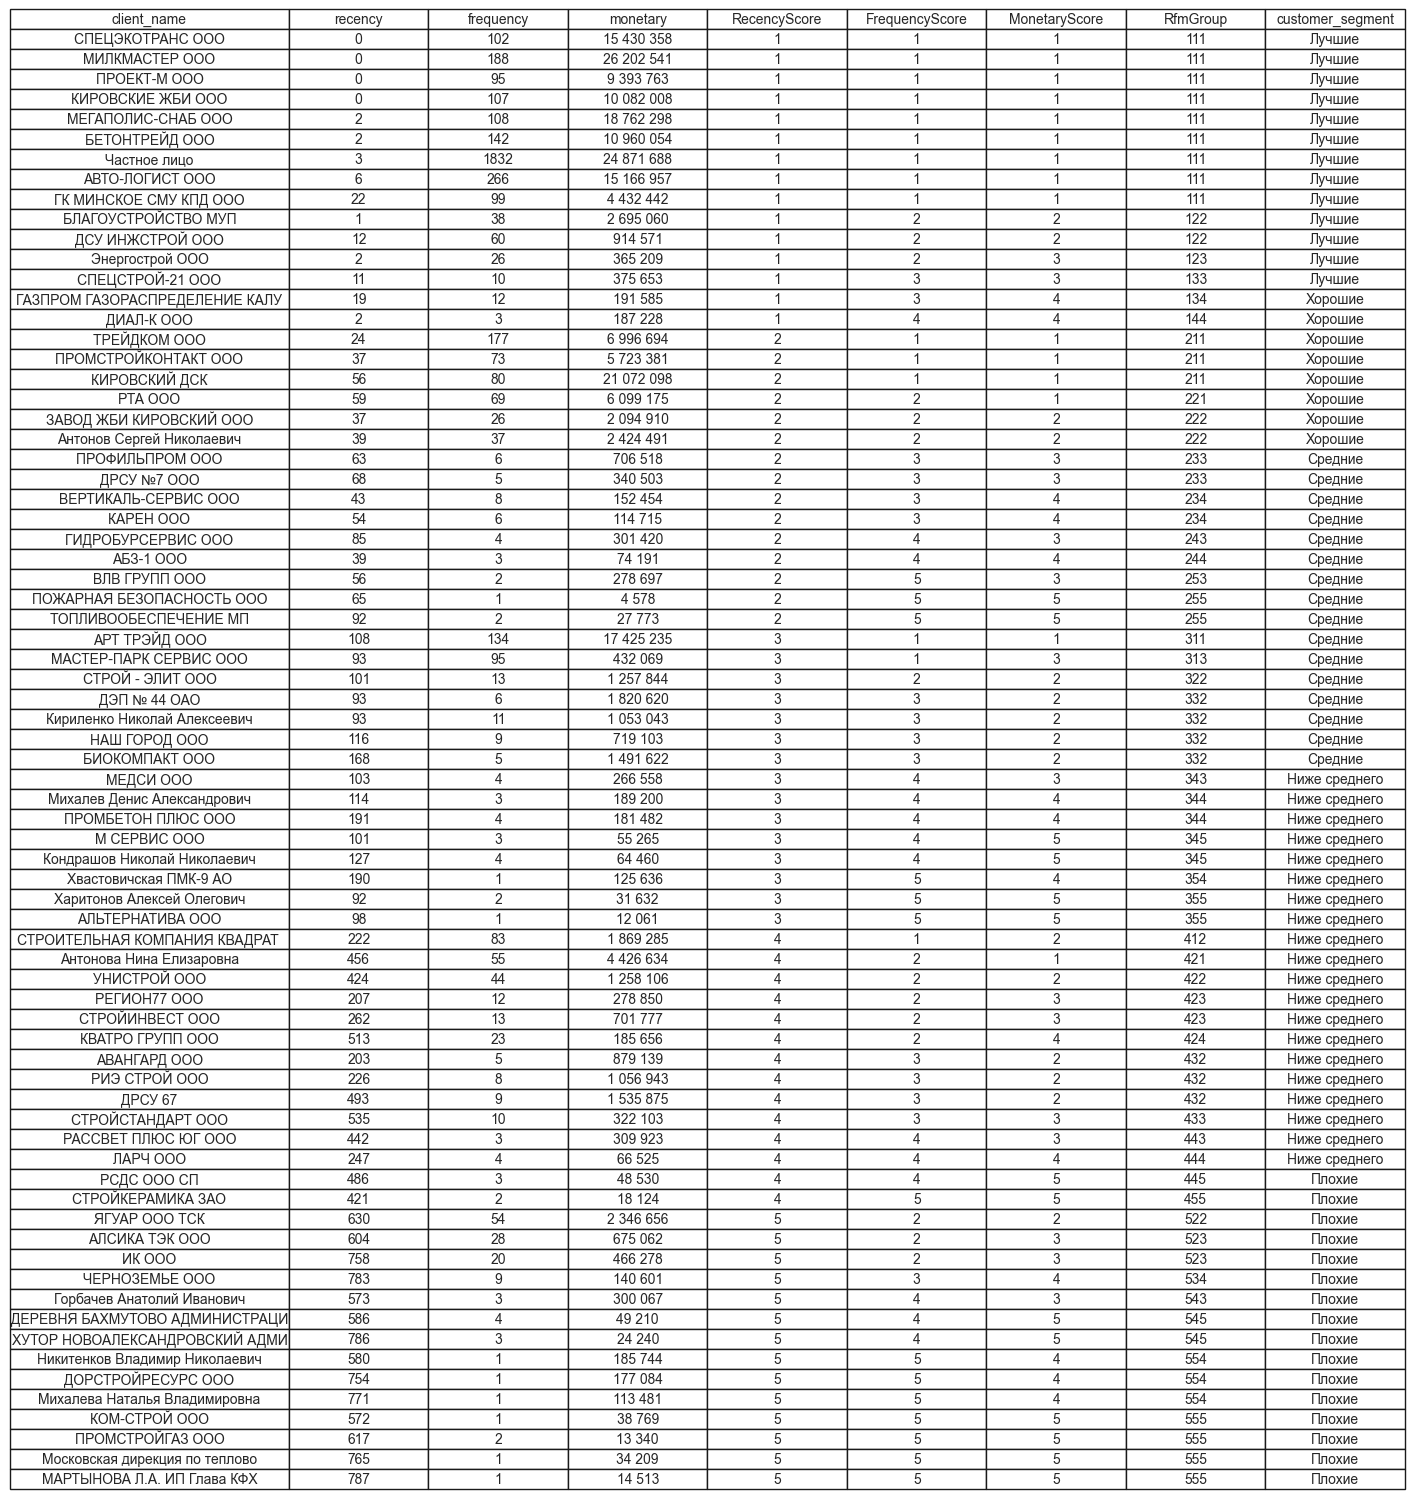

In [42]:
# Оформляем в виде таблицы для наглядности:

# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
df = pd.read_sql(rfm_query, conn)

# Закрытие соединения с базой данных.
conn.close()

# Удаление строк с NaN или пустыми значениями если они имеются.
df = df.dropna()

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{int(x):,}".replace(",", " ")
    return x

# Применение форматирования к указанным колонкам.
df['recency'] = df['recency'].apply(format_number)
df['monetary'] = df['monetary'].apply(format_number)

# Обрезка длинных названий клиентов до 30 символов.
df['client_name'] = df['client_name'].str.slice(0, 30)

# Создание таблицы с использованием matplotlib.
fig, ax = plt.subplots(figsize=(10, 8))  # Увеличение размера фигуры для лучшей читаемости.
ax.axis('tight')
ax.axis('off')

# Определение ширины столбцов.
col_widths = [0.15] * len(df.columns)
col_widths[0] = 0.3  # Увеличение ширины столбца client_name.

the_table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center', colWidths=col_widths)

# Установка размера шрифта для ячеек и заголовков.
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.2, 1.2)

# Отображение таблицы.
plt.show()

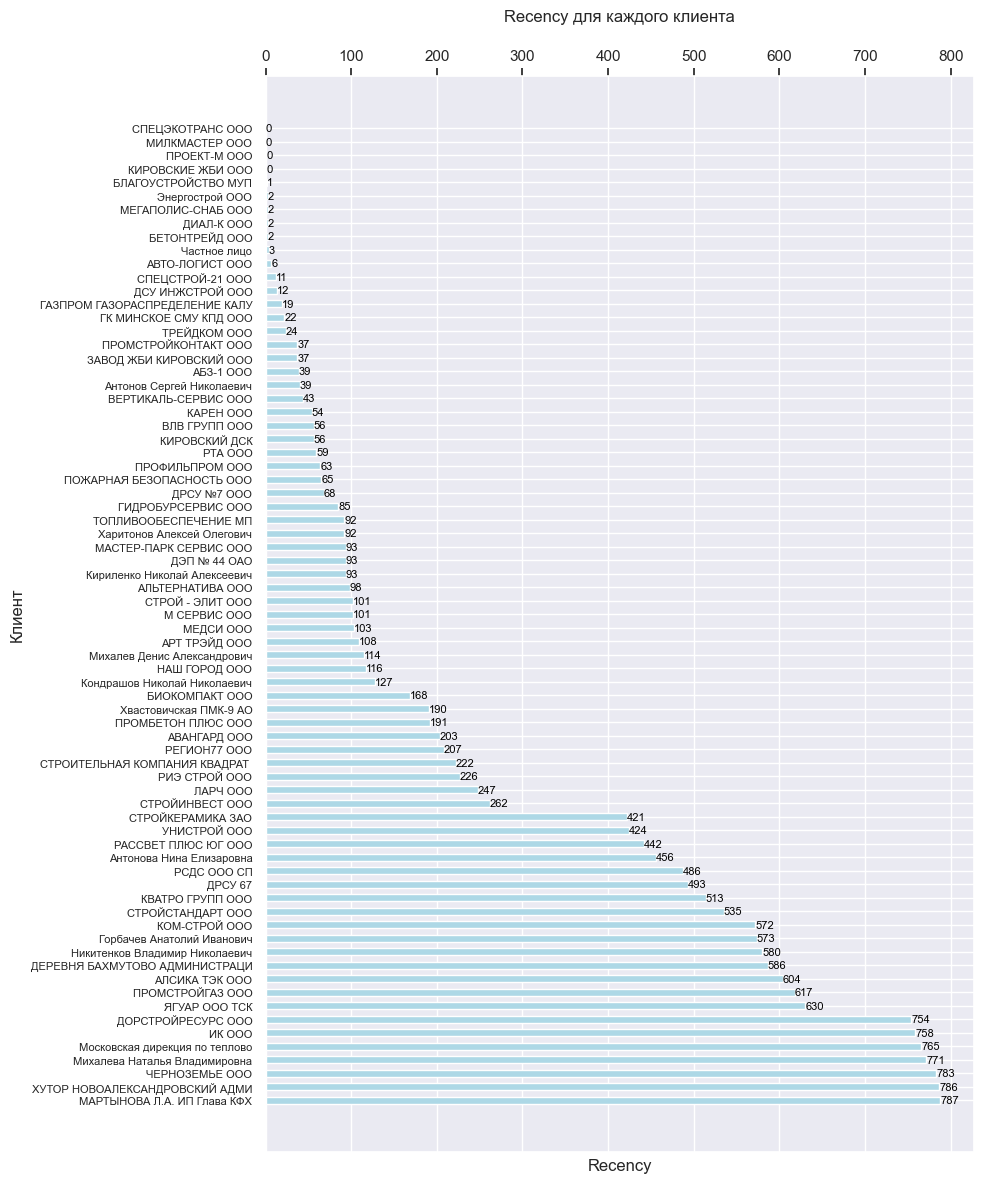

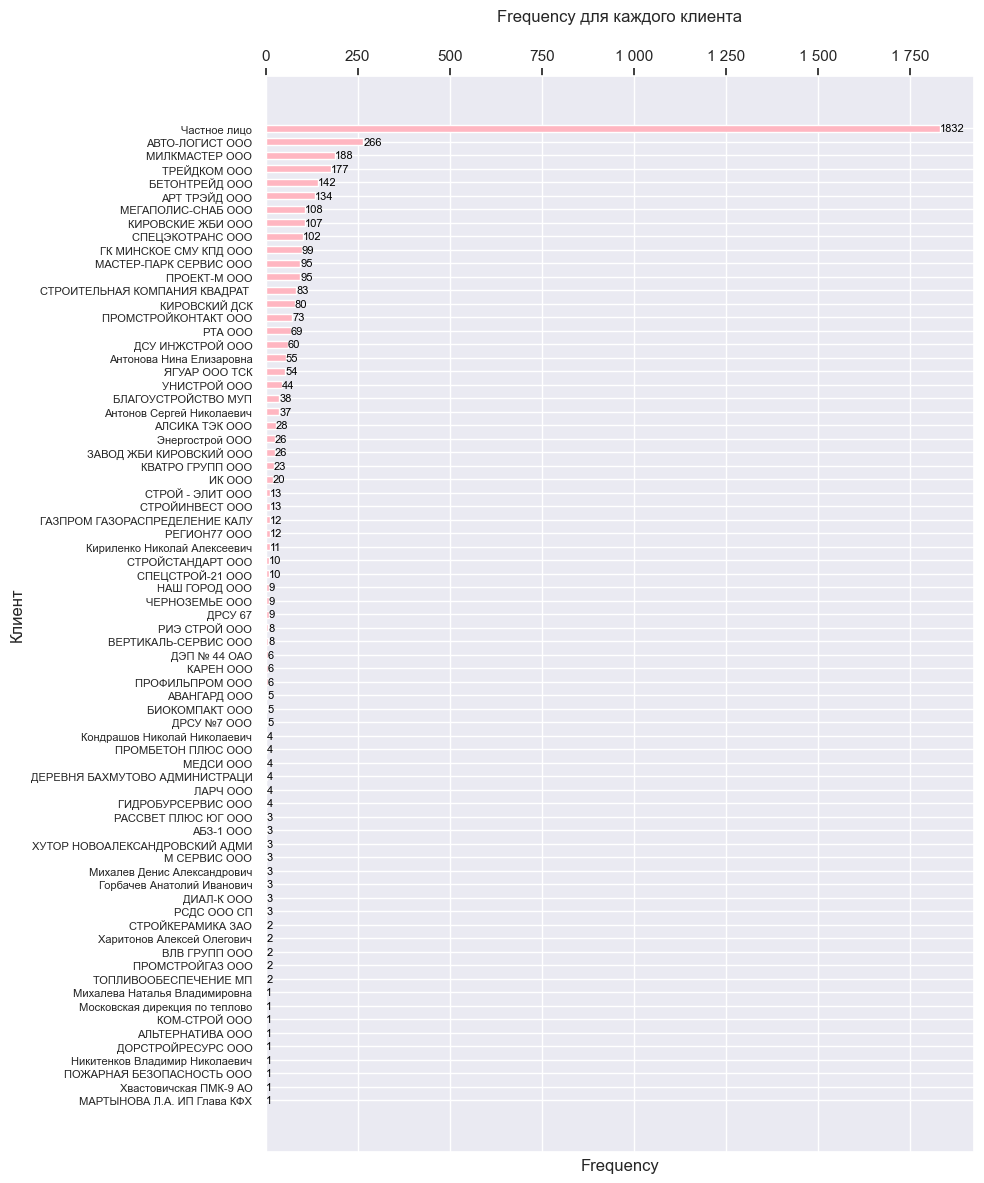

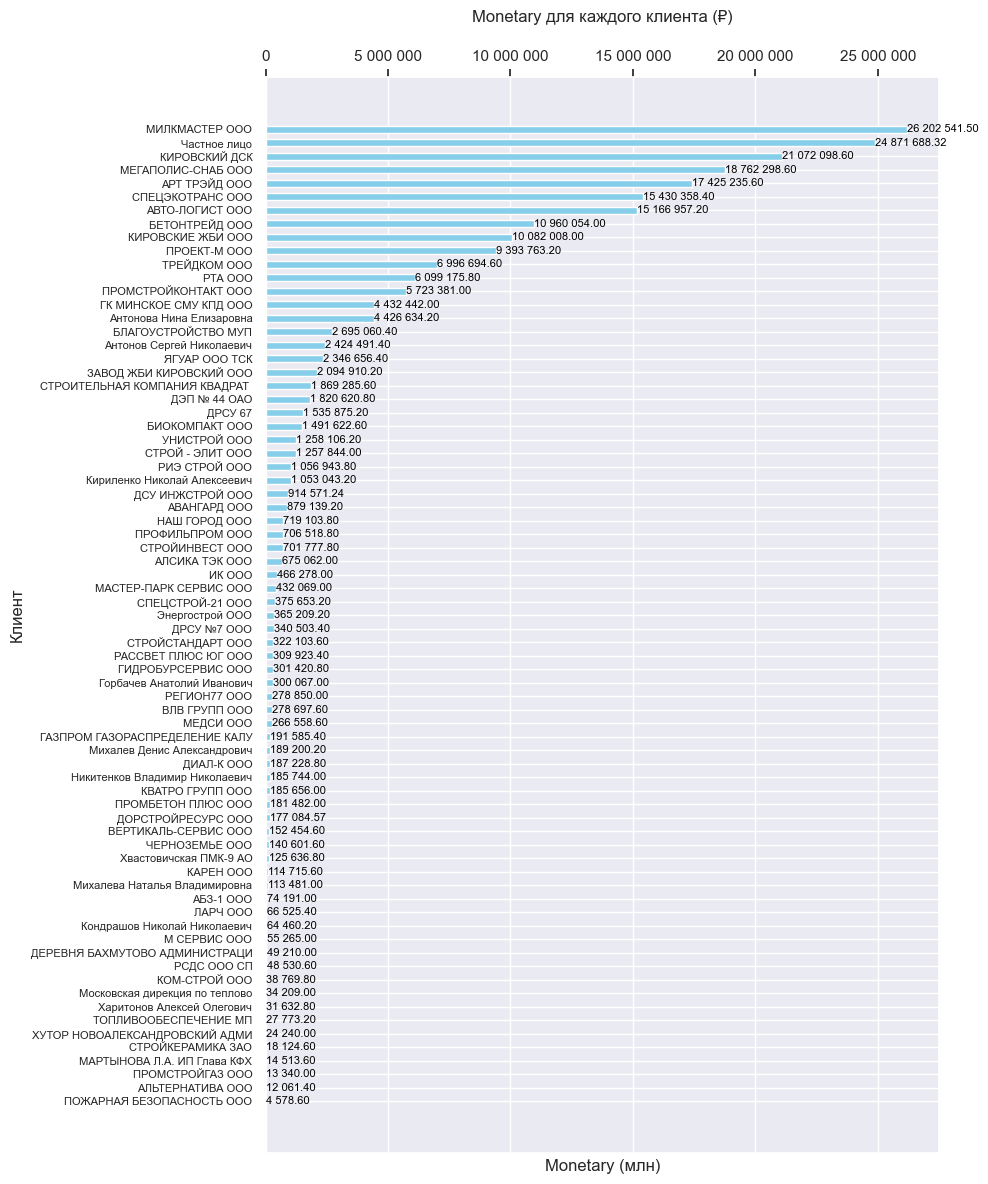

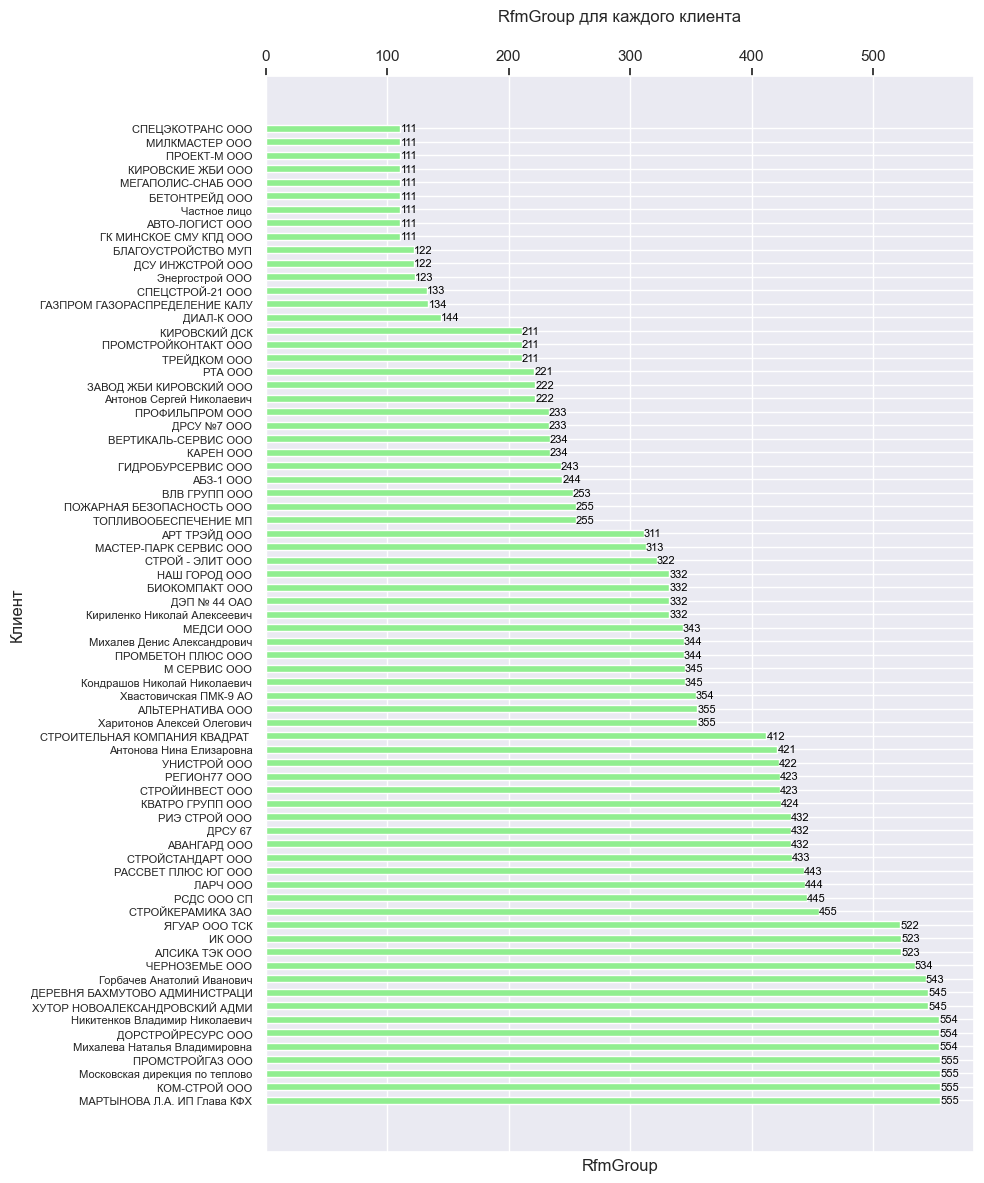

In [43]:
# Создаем графики по каждой метрике для наглядности:

# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
df = pd.read_sql(rfm_query, conn)

# Закрытие соединения с базой данных.
conn.close()

# Удаление строк с NaN или пустыми значениями если они имеются.
df = df.dropna()

# Обрезка длинных названий клиентов до 30 символов.
df['client_name'] = df['client_name'].str.slice(0, 30)

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Функция для форматирования процентов.
def format_percentage(x):
    if isinstance(x, (int, float)):
        return f"{x * 100:,.2f}%".replace(",", " ")
    return x

# Функция для добавления значений.
def add_labels(bars, formatter):
    for bar in bars:
        height = bar.get_width()
        formatted_height = formatter(height)
        plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                 formatted_height, va='center', ha='left', fontsize=8, color='black')

# Функция для форматирования оси X с разделителем.
def thousands(x, pos):
    return '{:,.0f}'.format(x).replace(',', ' ')

# Функция для форматирования оси X с разделителем.
def millions(x, pos):
    return '{:,.0f}'.format(x).replace(',', ' ')

formatter_thousands = FuncFormatter(thousands)
formatter_millions = FuncFormatter(millions)

# Сортировка данных.
df_monetary = df.sort_values(by='monetary', ascending=False)
df_rfmgroup = df.sort_values(by='RfmGroup', ascending=True)
df_recency = df.sort_values(by='recency', ascending=True)
df_frequency = df.sort_values(by='frequency', ascending=False)

# График Recency для каждого клиента.
plt.figure(figsize=(10, 12))
bars = plt.barh(df_recency['client_name'], df_recency['recency'], color='lightblue', height=0.5)
add_labels(bars, lambda x: int(x))  # Добавляем целые числа.
plt.xlabel('Recency')
plt.ylabel('Клиент')
plt.title('Recency для каждого клиента', pad=20)  # Добавляем отступ для заголовка.
plt.gca().invert_yaxis()  # Инвертируем ось Y, чтобы клиенты с наибольшим Recency были внизу.
plt.yticks(rotation=0, fontsize=8)  # Поворот меток и установка размера шрифта.
plt.gca().xaxis.set_ticks_position('top')  # Перемещение меток оси X наверх.
plt.gca().xaxis.set_major_formatter(formatter_thousands)  # Форматирование оси X.
plt.tight_layout()  # Автоматическая настройка отступов.
plt.show()  # Отображение графика.

# График Frequency для каждого клиента.
plt.figure(figsize=(10, 12))
bars = plt.barh(df_frequency['client_name'], df_frequency['frequency'], color='lightpink', height=0.5)
add_labels(bars, lambda x: int(x))  # Добавляем целые числа.
plt.xlabel('Frequency')
plt.ylabel('Клиент')
plt.title('Frequency для каждого клиента', pad=20)  # Добавляем отступ для заголовка.
plt.gca().invert_yaxis()  # Инвертируем ось Y, чтобы клиенты с наибольшим Frequency были вверху.
plt.yticks(rotation=0, fontsize=8)  # Поворот меток и установка размера шрифта.
plt.gca().xaxis.set_ticks_position('top')  # Перемещение меток оси X наверх.
plt.gca().xaxis.set_major_formatter(formatter_thousands)  # Форматирование оси X.
plt.tight_layout()  # Автоматическая настройка отступов.
plt.show()  # Отображение графика.

# График Monetary для каждого клиента.
plt.figure(figsize=(10, 12))
bars = plt.barh(df_monetary['client_name'], df_monetary['monetary'], color='skyblue', height=0.5)
add_labels(bars, format_number)  # Добавляем значения.
plt.xlabel('Monetary (млн)')
plt.ylabel('Клиент')
plt.title('Monetary для каждого клиента (₽)', pad=20)  # Добавляем отступ для заголовка.
plt.gca().invert_yaxis()  # Инвертируем ось Y, чтобы клиенты с наибольшим Monetary были вверху.
plt.yticks(rotation=0, fontsize=8)  # Поворот меток и установка размера шрифта.
plt.gca().xaxis.set_ticks_position('top')  # Перемещение меток оси X наверх.
plt.gca().xaxis.set_major_formatter(formatter_millions)  # Форматирование оси X.
plt.gca().xaxis.set_major_locator(MultipleLocator(5e6))  # Установка интервала меток оси X.
plt.tight_layout()  # Автоматическая настройка отступов.
plt.show()  # Отображение графика.

# График RfmGroup для каждого клиента.
plt.figure(figsize=(10, 12))
bars = plt.barh(df_rfmgroup['client_name'], df_rfmgroup['RfmGroup'].astype(int), color='lightgreen', height=0.5)
add_labels(bars, lambda x: int(x))  # Добавляем целые числа.
plt.xlabel('RfmGroup')
plt.ylabel('Клиент')
plt.title('RfmGroup для каждого клиента', pad=20)  # Добавляем отступ для заголовка.
plt.gca().invert_yaxis()  # Инвертируем ось Y, чтобы клиенты с наибольшим RfmGroup были внизу.
plt.yticks(rotation=0, fontsize=8)  # Поворот меток и установка размера шрифта.
plt.gca().xaxis.set_ticks_position('top')  # Перемещение меток оси X наверх.
plt.gca().xaxis.set_major_formatter(formatter_thousands)  # Форматирование оси X.
plt.tight_layout()  # Автоматическая настройка отступов.
plt.show()  # Отображение графика.

In [44]:
# Визуализируем данные по сегментам (колонка customer_segment):

# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
df = pd.read_sql(rfm_query, conn)

# Закрытие соединения с базой данных.
conn.close()

# Удаление строк с NaN или пустыми значениями если они имеются.
df = df.dropna()

# Группировка данных по сегментам клиентов и подсчет количества клиентов и суммарных значений monetary.
segment_data = df.groupby('customer_segment').agg({'monetary': 'sum', 'client_name': 'count'}).reset_index()
segment_data.rename(columns={'client_name': 'count'}, inplace=True)

# Создание Treemap Graph.
fig = px.treemap(segment_data,
                 path=['customer_segment'],
                 values='monetary',
                 color='monetary',
                 color_continuous_scale='turbo',
                 title='Древовидная карта сегментов',
                 hover_data={'monetary': ':,.2f', 'count': True})

# Настройка шаблона всплывающей подсказки.
fig.update_traces(hovertemplate="""
<b>Сегмент:</b> %{label}<br>
<b>Сумма Monetary:</b> %{value:,.2f}<br>
<b>Количество клиентов:</b> %{customdata[1]}
""")

# Сохранение графика как изображения.
fig.write_image("rfm_treemap.png")

# Отображение графика.
fig.show()

![Древовидная карта сегментов](rfm_treemap.png)

In [45]:
# Посмотрим отдельно количество клиентов и сумму в каждом сегменнте в виде таблицы:

# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

df = pd.read_sql(rfm_query, conn)

# Закрытие соединения с базой данных.
conn.close()

# Удаление строк с NaN или пустыми значениями если они имеются.
df = df.dropna()

# Группировка данных по сегментам клиентов и подсчет количества клиентов и суммарных значений monetary.
segment_data = df.groupby('customer_segment').agg({'monetary': 'sum', 'client_name': 'count'}).reset_index()
segment_data.rename(columns={'client_name': 'count'}, inplace=True)

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Применение функции форматирования к столбцу monetary.
segment_data['monetary'] = segment_data['monetary'].apply(format_number)

# Определение порядка сегментов.
segment_order = ['Лучшие', 'Хорошие', 'Средние', 'Ниже среднего', 'Плохие', 'Неизвестно']

# Создание столбца для сортировки.
segment_data['segment_order'] = segment_data['customer_segment'].map({segment: i for i, segment in enumerate(segment_order)})

# Сортировка данных по порядку сегментов.
segment_data = segment_data.sort_values(by='segment_order').drop(columns='segment_order')

# Отображение результатов.
segment_data

,customer_segment,monetary,count
0,Лучшие,139 652 605.26,13
4,Хорошие,44 789 565.80,8
3,Средние,26 200 392.60,16
1,Ниже среднего,13 817 117.40,20
2,Плохие,4 645 912.17,16


In [46]:
# Визуализируем данные по сумме Monetary:

from IPython.display import HTML, display

# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
df = pd.read_sql(rfm_query, conn)

# Закрытие соединения с базой данных.
conn.close()

# Удаление строк с NaN или пустыми значениями если они имеются.
df = df.dropna()

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Функция для объединения уникальных значений в список.
def join_unique_names(x):
    return ', '.join(x.dropna().unique().astype(str))

# Группировка данных по столбцу RfmGroup и агрегирование данных.
rfm_grouped = (
    df.groupby('RfmGroup')  # Группировка данных по столбцу RfmGroup.
       .agg({'client_name': join_unique_names,  # Объединение уникальных значений в список.
             'monetary': 'sum'})
       .reset_index()  # Сбросим индексы.
       .round({'monetary': 2})  # Округление значений до 2 знаков после запятой.
       .nlargest(71, 'monetary')  # Выбор строк с наибольшими значениями в столбце.
)

# Сохранение числовых значений для вычислений.
rfm_grouped['monetary_numeric'] = rfm_grouped['monetary']

# Применение форматирования к столбцу 'monetary'.
rfm_grouped['monetary'] = rfm_grouped['monetary'].apply(format_number)

# Функция для создания HTML-таблицы с заливкой-индикатором.
def create_html_table_with_bar(df, bar_column):
    # Нормализация значений для заливки.
    max_value = df[bar_column].max()
    df['bar_width'] = df[bar_column] / max_value * 100

    # Создание HTML-таблицы.
    html_table = df.drop(columns=['bar_width', bar_column]).to_html(index=False, escape=False)

    # Добавление стилей для заливки-индикатора и ширины столбца.
    def add_bar(match):
        value = match.group(1)
        try:
            width = df.loc[df[bar_column] == float(value.replace(" ", "")), 'bar_width'].values[0]
        except IndexError:
            width = 0  # Если значение не найдено, устанавливаем ширину в 0.
        return f'<td style="background: linear-gradient(to right, lightgreen {width}%, white {width}%); width: 200px;">{value}</td>'

    html_table = re.sub(r'<td>([\d,. ]+)</td>', add_bar, html_table)

    # Добавление CSS-стилей для ширины столбцов.
    html_table = html_table.replace('<table', '<table style="width: 100%; table-layout: fixed;"')
    html_table = html_table.replace('<th>RfmGroup</th>', '<th style="width: 150px;">RfmGroup</th>')
    html_table = html_table.replace('<th>monetary</th>', '<th style="width: 200px;">monetary</th>')

    return html_table

# Создание HTML-таблицы с индикатором для столбца 'monetary_numeric'.
html_table = create_html_table_with_bar(rfm_grouped, 'monetary_numeric')

# Сохранение HTML-таблицы в файл.
with open('rfm_monetary_table.html', 'w') as f:
    f.write(html_table)

# Отображение HTML-таблицы.
display(HTML(html_table))

RfmGroup,client_name,monetary
111,"СПЕЦЭКОТРАНС ООО, МИЛКМАСТЕР ООО, ПРОЕКТ-М ООО, КИРОВСКИЕ ЖБИ ООО, МЕГАПОЛИС-СНАБ ООО, БЕТОНТРЕЙД ООО, Частное лицо, АВТО-ЛОГИСТ ООО, ГК МИНСКОЕ СМУ КПД ООО",135 302 111.22
211,"ТРЕЙДКОМ ООО, ПРОМСТРОЙКОНТАКТ ООО, КИРОВСКИЙ ДСК",33 792 174.20
311,АРТ ТРЭЙД ООО,17 425 235.60
221,РТА ООО,6 099 175.80
332,"ДЭП № 44 ОАО, Кириленко Николай Алексеевич, НАШ ГОРОД ООО, БИОКОМПАКТ ООО",5 084 390.40
222,"ЗАВОД ЖБИ КИРОВСКИЙ ООО, Антонов Сергей Николаевич",4 519 401.60
421,Антонова Нина Елизаровна,4 426 634.20
122,"БЛАГОУСТРОЙСТВО МУП, ДСУ ИНЖСТРОЙ ООО",3 609 631.64
432,"АВАНГАРД ООО, РИЭ СТРОЙ ООО, ДРСУ 67",3 471 958.20
522,ЯГУАР ООО ТСК,2 346 656.40


Общие объяснения оценки анализа.

**Интерпретация оценки 111**

RecencyScore = 1: Клиент совсем недавно совершал покупку.

FrequencyScore = 1: Клиент часто совершает покупки.

MonetaryScore = 1: Клиент тратит много денег (с высоким чеком).

Таким образом, оценка 111 означает, что клиент совсем недавно совершал покупку, часто совершает покупки и тратит много денег. Это самые лучшие показатели, которые можно получить в данном контексте.

____________________________________________________________________________________________________________________

**Интерпретация оценки 222** указывает на клиента, который имеет средние показатели по всем трем параметрам RFM. 

Это означает, что клиент:

RecencyScore = 2: Недавние покупки.

FrequencyScore = 2: Редкие покупки.

MonetaryScore = 2: С чеком выше среднего.

Таким образом, клиент с оценкой 222 является недавним клиентом, который совершает редкие покупки с чеком выше среднего.

____________________________________________________________________________________________________________________

**Интерпретация оценки 333** указывает на клиента, который имеет показатели, находящиеся в пределах одного стандартного отклонения от среднего значения по всем трем параметрам RFM. 

Это означает, что клиент:

RecencyScore = 3: "Спящие" клиенты.

FrequencyScore = 3: Довольно редкие покупки.

MonetaryScore = 3: Со средним чеком.

Таким образом, клиент с оценкой 333 является клиентом, который не выделяется ни в лучшую, ни в худшую сторону по сравнению с другими клиентами, но находится в пределах одного стандартного отклонения от среднего значения.

_____________________________________________________________________________________________________________________

**Интерпретация оценки 444** указывает на клиента, который имеет одни из самых низких показатели по всем трем параметрам RFM. 

Это означает, что клиент:

RecencyScore = 4: Давние клиенты.

FrequencyScore = 4: Очень редкие покупки.

MonetaryScore = 4: С чеком ниже среднего.

Таким образом, клиент с оценкой 444 является наименее активным и наименее ценным клиентом по сравнению с другими клиентами. 

_____________________________________________________________________________________________________________________

**Интерпретация оценки 555** указывает на клиента, который имеет самые низкие показатели по всем трем параметрам RFM. 

Это означает, что клиент:

RecencyScore = 5: Давние клиенты.

FrequencyScore = 5: Крайне редкие покупки.

MonetaryScore = 5: С низким чеком.

Таким образом, клиент с оценкой 555 является самым неактивным и наименее ценным клиентом по сравнению с другими клиентами. 

Это может указывать на то, что клиент либо потерял интерес к вашему продукту или услуге, либо никогда не был активным покупателем.

<a id="4.2-Средний-чек"></a>
### **Средний чек**
[↑ Наверх](#top)

Метрика отражает среднюю сумму потраченную одним клиентом за весь рассматриваемый период с 01.11.2022 по 28.12.2024 года.

In [47]:
avg_check_sql = '''
SELECT 
       customer AS client_name,
       AVG(amount) AS average_check
FROM sales
GROUP BY customer
ORDER BY average_check DESC
'''

In [48]:
# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
Avg_check = pd.read_sql(avg_check_sql, conn)

# Удаление строк с пустыми значениями в столбцах product и client_name если они есть.
Avg_check = Avg_check.dropna(subset=['client_name'])

# Удаление строк с пустыми значениями в столбце average_check если они есть.
Avg_check = Avg_check.dropna(subset=['average_check'])

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Применение функции форматирования к столбцу average_check.
Avg_check['average_check'] = Avg_check['average_check'].apply(format_number)

# Отображение данных.
Avg_check.head(10)

,client_name,average_check
0,ДЭП № 44 ОАО,303 436.80
1,БИОКОМПАКТ ООО,298 324.52
2,КИРОВСКИЙ ДСК,263 401.23
3,Никитенков Владимир Николаевич,185 744.00
4,ДОРСТРОЙРЕСУРС ООО,177 084.57
5,АВАНГАРД ООО,175 827.84
6,МЕГАПОЛИС-СНАБ ООО,173 724.99
7,ДРСУ 67,170 652.80
8,СПЕЦЭКОТРАНС ООО,151 278.02
9,МИЛКМАСТЕР ООО,139 375.22


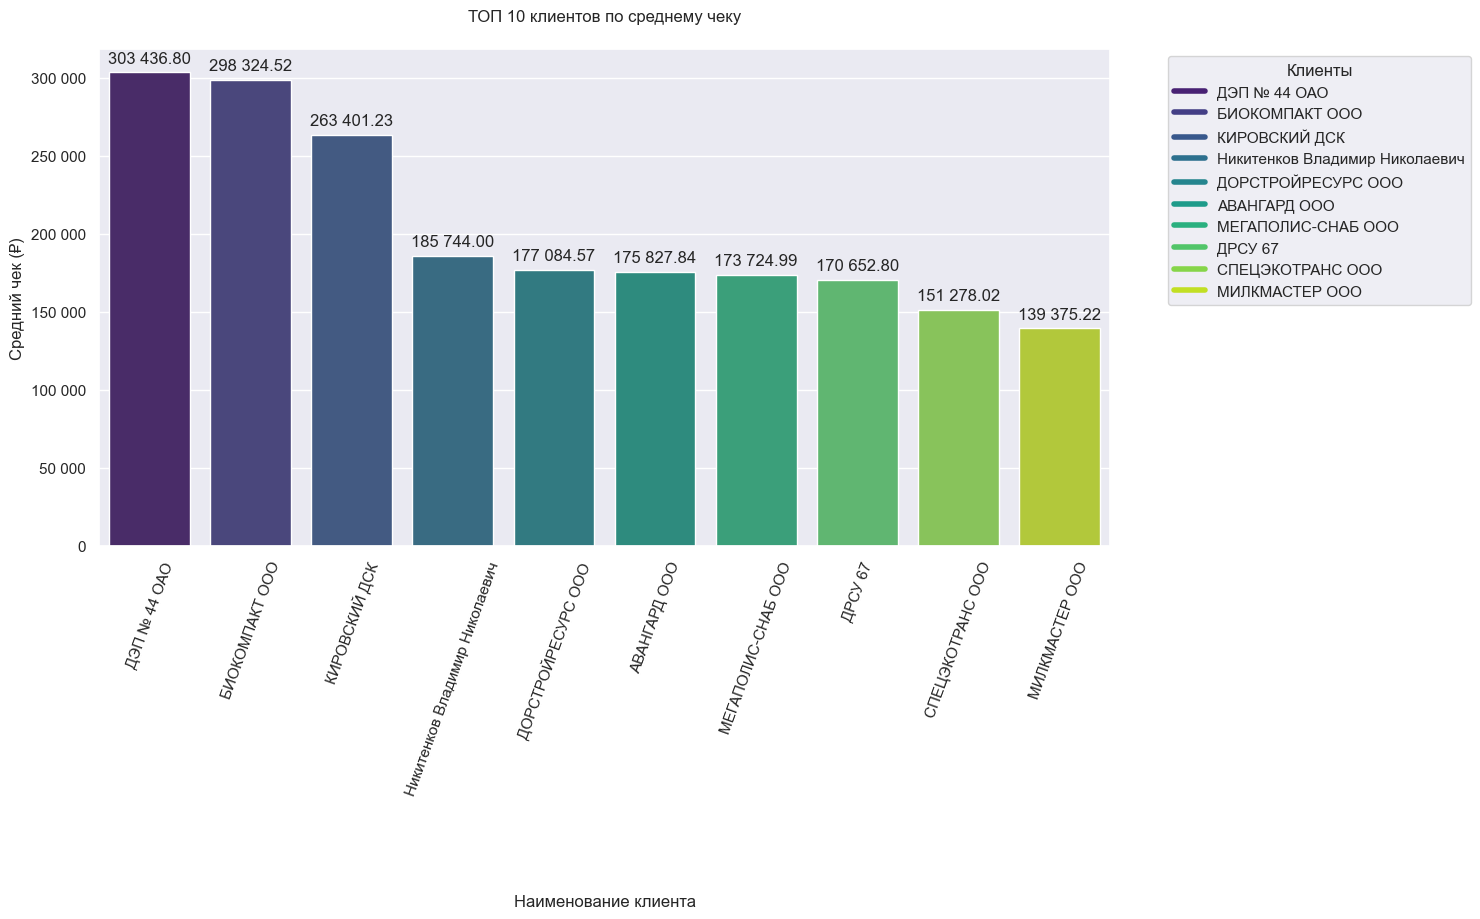

In [49]:
# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
df = pd.read_sql(avg_check_sql, conn)

# Ограничение выводимых данных.
df = df.head(10)

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Визуализация данных.
plt.figure(figsize=(10, 8))
ax = sns.barplot(x='client_name', y='average_check', data=df, palette='viridis')

# Форматирование оси Y с разделителем.
def thousands(x, pos):
    return '{:,.0f}'.format(x).replace(',', ' ')

formatter = FuncFormatter(thousands)
ax.yaxis.set_major_formatter(formatter)

plt.title('ТОП 10 клиентов по среднему чеку', pad=20)  # Добавляем отступ для заголовка.
plt.xlabel('Наименование клиента', labelpad=70)  # Добавление отступа для метки оси X.
plt.ylabel('Средний чек (₽)')
plt.xticks(rotation=70, ha='center')  # Поворачиваем метки оси X и центрируем их.
plt.tight_layout(pad=-3)

# Добавляем значения данных average_check поверх столбцов с разделителями и двумя знаками после запятой.
for p in ax.patches:
    height = p.get_height()
    formatted_height = format_number(height)
    ax.annotate(f'{formatted_height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 5),
                textcoords='offset points')

# Создание легенды.
colors = sns.color_palette('viridis', len(df))
legend_elements = [Line2D([0], [0], color=colors[i], lw=4, label=df['client_name'].iloc[i]) for i in range(len(df))]
ax.legend(handles=legend_elements, title='Клиенты', bbox_to_anchor=(1.05, 1), loc='upper left')

# Отображение графика.
plt.show()

# Вывод данных.
conn.close()

Больше всего средний чек у трёх компании: 

ДЭП № 44 ОАО - средний чек 303 436.80₽;

Ниже идет компания БИОКОМПАКТ ООО - средний чек 298 324.52₽;

На третьем месте КИРОВСКИЙ ДСК - средний чек 263 401.23₽;

и далее по списку.

**Теперь посмотрим среднюю сумму потраченную одним клиентом сгруппированную по продукции за весь период**

In [50]:
avg_check_by_prod_sql = '''
SELECT product,
       customer AS client_name,
       AVG(amount) AS average_check
FROM sales
GROUP BY product, client_name
ORDER BY average_check DESC
'''

In [51]:
# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
avg_check_by_prod = pd.read_sql(avg_check_by_prod_sql, conn)

# Удаление строк с пустыми значениями в столбцах product и client_name если они есть.
avg_check_by_prod = avg_check_by_prod.dropna(subset=['product', 'client_name'])

# Удаление строк с пустыми значениями в столбце average_check если они есть.
avg_check_by_prod = avg_check_by_prod.dropna(subset=['average_check'])

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Применение функции форматирования к столбцу average_check.
avg_check_by_prod['average_check'] = avg_check_by_prod['average_check'].apply(format_number)

# Вывод данных.
avg_check_by_prod.head(10)

,product,client_name,average_check
0,Щебень 20х40,КИРОВСКИЙ ДСК,382 500.56
1,Щебень 5х20,БИОКОМПАКТ ООО,323 787.50
2,Щебень 20х40,ДЭП № 44 ОАО,303 436.80
3,Щебень 20х40,БИОКОМПАКТ ООО,281 349.20
4,Щебень 5х20,КИРОВСКИЙ ДСК,240 496.48
5,Гравий 20х40,Никитенков Владимир Николаевич,185 744.00
6,Щебень 20х40,ПРОЕКТ-М ООО,181 291.17
7,Песок строительный,ДОРСТРОЙРЕСУРС ООО,177 084.57
8,Щебень 5х20,АВАНГАРД ООО,176 995.20
9,Щебень 20х40,МИЛКМАСТЕР ООО,176 505.38


КИРОВСКИЙ ДСК выберает Щебень 20х40	в среднем на 382 500.56₽, Щебень 5х20 на 240 496.48₽;

БИОКОМПАКТ ООО выберает Щебень 5х20 в среднем на 323 787.50₽, Щебень 20х40 на 281 349.20₽;

ДЭП № 44 ОАО выберает Щебень 20х40 в среднем на 303 436.80₽.

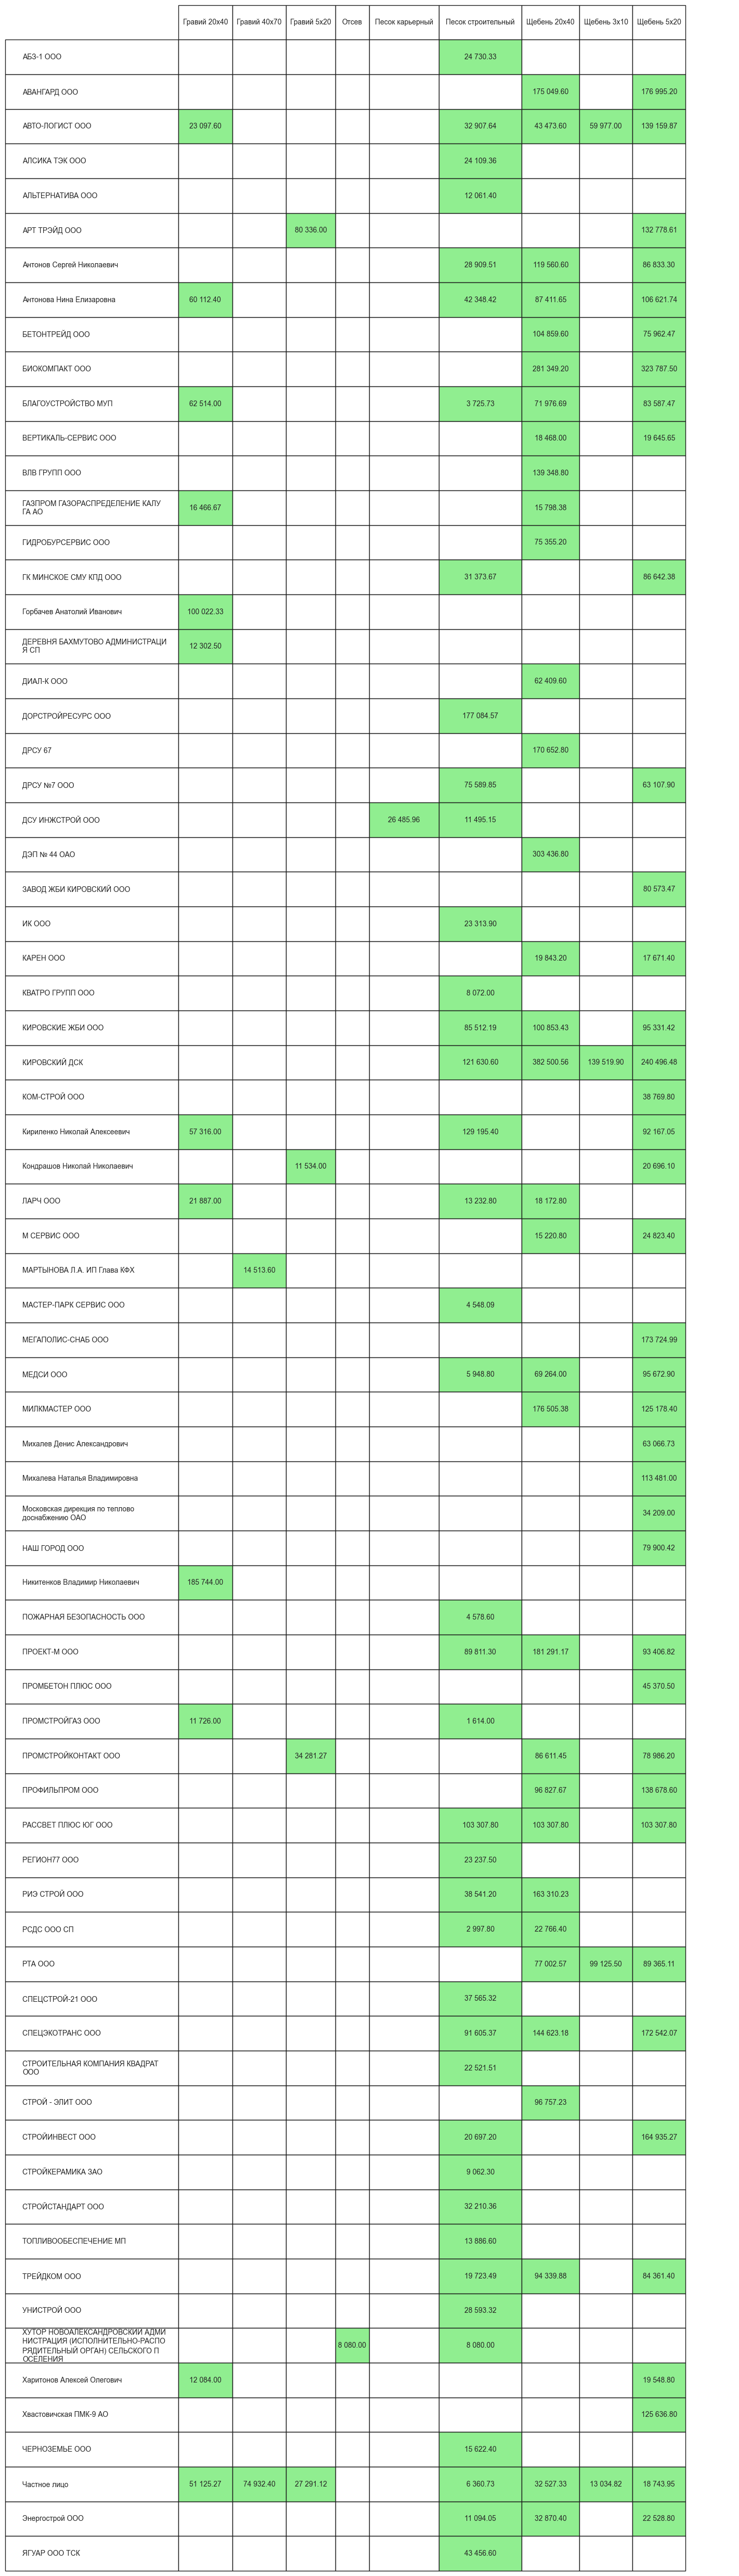

In [52]:
# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
df = pd.read_sql_query(avg_check_by_prod_sql, conn)

# Закрытие соединения с базой данных.
conn.close()

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return ""

# Удаление строк с пустыми значениями в столбце product если они есть.
df = df.dropna(subset=['product'])

# Перестройка датафрейма для визуализации.
pivot_df = df.pivot(index='client_name', columns='product', values='average_check')

# Удаление строк и столбцов с пустыми данными если они есть.
pivot_df = pivot_df.dropna(axis=0, how='all').dropna(axis=1, how='all')

# Заполнение оставшихся NaN значений пустыми строками.
pivot_df = pivot_df.fillna("")

# Функция для переноса длинных названий клиентов.
def wrap_client_name(name):
    if len(name) > 30:
        return '\n'.join([name[i:i+30] for i in range(0, len(name), 30)])
    return name

# Применение функции переноса к названиям клиентов.
pivot_df.index = pivot_df.index.map(wrap_client_name)

# Стилизация.
def highlight_nonzero(val):
    color = 'lightgreen' if val != "" else ''
    return f'background-color: {color};'

# Применение стиля к ячейкам на основе условий.
styled_df = (
    pivot_df
       .style.format(format_number)  # Форматирование значений с разделителем.
       .applymap(highlight_nonzero)  # Применение стиля к ячейкам на основе условий.
       .set_properties(**{'text-align': 'right'})  # Выравнивание текста по правому краю.
       .set_table_styles([
           {'selector': 'thead th', 'props': [('text-align', 'center')]},  # Центрирование заголовков.
           {'selector': 'tbody td', 'props': [('vertical-align', 'top')]},  
           # Вертикальное выравнивание текста по верхнему краю.
           {'selector': 'tbody td:first-child', 'props': [
               ('white-space', 'normal'), ('word-wrap', 'break-word'), 
               ('width', '300px')]}  # Обертка текста в первом столбце.
       ])
)

# Создание изображения.
fig, ax = plt.subplots(figsize=(15, 20))  # Увеличение высоты фигуры.
ax.axis('off')  # Отключение осей.
ax.axis('tight')  # Установка границ осей.

# Отображение таблицы.
table = ax.table(cellText=pivot_df.applymap(format_number).values, colLabels=pivot_df.columns, rowLabels=pivot_df.index,
                 cellColours=[['lightgreen' if val != "" else 'white' for val in row] for row in pivot_df.values],
                 cellLoc='center', loc='center')

# Настройка ширины первого столбца.
table.auto_set_column_width(col=list(range(len(pivot_df.columns))))
table.auto_set_column_width(col=0)

# Настройка стиля таблицы.
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.5, 4.0)  # Увеличение высоты строк.

# Сохранение изображения в файл.
plt.savefig('styled_table.png', bbox_inches='tight', pad_inches=0.1)

# Отображение изображения.
plt.show()

![Средняя сумма потраченная одним клиентом сгруппированная по продукции за весь период](styled_table.html)

<a id="4.3-Retention-Rate"></a>
### **Retention Rate**
[↑ Наверх](#top)

Retention Rate (коэффициент удержания) — это метрика, которая измеряет процент пользователей, клиентов или сотрудников, которые остаются с компанией или продуктом в течение определенного периода времени. 

Клиенты:

Измеряет, сколько клиентов продолжают покупать продукицю компании.

In [53]:
rr_sql = '''
-- CTE для вычисления даты первой покупки для каждого клиента.
-- first_purchase_date: дата первой покупки клиента.
    
WITH first_purchases AS (
    SELECT
        customer,
        MIN(date) AS first_purchase_date
    FROM sales
    GROUP BY customer
),

-- CTE для вычисления дат повторных покупок для каждого клиента.
-- repeat_purchase_date: дата повторной покупки клиента.

repeat_purchases AS (
    SELECT
        customer,
        date AS repeat_purchase_date
    FROM sales
    WHERE date > (SELECT first_purchase_date FROM first_purchases WHERE sales.customer = first_purchases.customer)
),

-- CTE для вычисления общего количества уникальных клиентов по месяцам.
-- year_month: год и месяц.
-- total_customers: общее количество уникальных клиентов в месяц.

monthly_customers AS (
    SELECT
        strftime('%Y-%m', date) AS year_month,
        COUNT(DISTINCT customer) AS total_customers
    FROM sales
    GROUP BY strftime('%Y-%m', date)
),

-- CTE для вычисления количества удержанных клиентов (повторных покупок) по месяцам.
-- year_month: год и месяц.
-- retained_customers: количество удержанных клиентов в месяц.

monthly_retained_customers AS (
    SELECT
        strftime('%Y-%m', repeat_purchase_date) AS year_month,
        COUNT(DISTINCT customer) AS retained_customers
    FROM repeat_purchases
    GROUP BY strftime('%Y-%m', repeat_purchase_date)
)

-- Основной запрос для вычисления удержания клиентов по месяцам.

SELECT
    mc.year_month,
    mc.total_customers,
    COALESCE(mrc.retained_customers, 0) AS retained_customers,
    CASE
        WHEN mc.total_customers > 0 THEN
            ROUND(COALESCE(mrc.retained_customers, 0) * 100.0 / mc.total_customers, 2)
        ELSE
            0.0
    END AS retention_rate
FROM monthly_customers mc
LEFT JOIN monthly_retained_customers mrc ON mc.year_month = mrc.year_month
'''

In [54]:
# Чтение данных из базы данных и загрузка их в датафейм.
retention_rate = pd.read_sql(rr_sql, con=engine)

# Вывод данных.
retention_rate

,year_month,total_customers,retained_customers,retention_rate
0,2022-11,12,7,58.33
1,2022-12,6,4,66.67
2,2023-01,3,3,100.00
3,2023-02,3,3,100.00
4,2023-03,5,5,100.00
5,2023-04,11,10,90.91
6,2023-05,13,10,76.92
7,2023-06,15,13,86.67
8,2023-07,17,17,100.00
9,2023-08,17,17,100.00


**Здесь смотрим, какие именно клиенты попали в список удержания retained_customers_list**

In [55]:
rr_sql = '''
-- CTE для вычисления даты первой покупки для каждого клиента.
-- first_purchase_date: дата первой покупки клиента.
    
WITH first_purchases AS (
    SELECT
        customer,
        MIN(date) AS first_purchase_date
    FROM sales
    GROUP BY customer
),

-- CTE для вычисления дат повторных покупок для каждого клиента.
-- repeat_purchase_date: дата повторной покупки клиента.

repeat_purchases AS (
    SELECT
        customer,
        date AS repeat_purchase_date
    FROM sales
    WHERE date > (SELECT first_purchase_date FROM first_purchases WHERE sales.customer = first_purchases.customer)
),

-- CTE для вычисления общего количества уникальных клиентов по месяцам.
-- year_month: год и месяц.
-- total_customers: общее количество уникальных клиентов в месяц.

monthly_customers AS (
    SELECT
        strftime('%Y-%m', date) AS year_month,
        COUNT(DISTINCT customer) AS total_customers
    FROM sales
    GROUP BY strftime('%Y-%m', date)
),

-- CTE для вычисления количества удержанных клиентов (повторных покупок) по месяцам.
-- year_month: год и месяц.
-- retained_customers: количество удержанных клиентов в месяц.
-- retained_customers_list: список удержанных клиентов в месяц.

monthly_retained_customers AS (
    SELECT
        strftime('%Y-%m', repeat_purchase_date) AS year_month,
        COUNT(DISTINCT customer) AS retained_customers,
        GROUP_CONCAT(DISTINCT customer) AS retained_customers_list --Оконная ф-ция для объединения уникальных клиентов в строку.
    FROM repeat_purchases
    GROUP BY strftime('%Y-%m', repeat_purchase_date)
)

-- Основной запрос для вычисления удержания клиентов по месяцам.

SELECT
    mc.year_month,
    mc.total_customers,
    COALESCE(mrc.retained_customers, 0) AS retained_customers,
    COALESCE(mrc.retained_customers_list, '') AS retained_customers_list,
    CASE
        WHEN mc.total_customers > 0 THEN
            ROUND(COALESCE(mrc.retained_customers, 0) * 100.0 / mc.total_customers, 2)
        ELSE
            0.0
    END AS retention_rate
FROM monthly_customers mc
LEFT JOIN monthly_retained_customers mrc ON mc.year_month = mrc.year_month
'''

In [56]:
# Чтение данных из базы данных и загрузка их в датафрейм.
retention_rate_list = pd.read_sql(rr_sql, con=engine)

# Вывод данных.
retention_rate_list

,year_month,total_customers,retained_customers,retained_customers_list,retention_rate
0,2022-11,12,7,"АРТ ТРЭЙД ООО,ЧЕРНОЗЕМЬЕ ООО,Частное лицо,ИК ООО,АВТО-ЛОГИСТ ООО,МАСТЕР-ПАРК СЕРВИС ООО,Антонова Нина Елизаровна",58.33
1,2022-12,6,4,"АВТО-ЛОГИСТ ООО,АРТ ТРЭЙД ООО,Частное лицо,ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕНИЕ КАЛУГА АО",66.67
2,2023-01,3,3,"Частное лицо,АВТО-ЛОГИСТ ООО,АРТ ТРЭЙД ООО",100.00
3,2023-02,3,3,"Частное лицо,АРТ ТРЭЙД ООО,ЯГУАР ООО ТСК",100.00
4,2023-03,5,5,"ЯГУАР ООО ТСК,МАСТЕР-ПАРК СЕРВИС ООО,АВТО-ЛОГИСТ ООО,Частное лицо,АЛСИКА ТЭК ООО",100.00
5,2023-04,11,10,"ЯГУАР ООО ТСК,Частное лицо,АЛСИКА ТЭК ООО,АВТО-ЛОГИСТ ООО,Антонова Нина Елизаровна,АРТ ТРЭЙД ООО,ПРОМСТРОЙГАЗ ООО,МА...",90.91
6,2023-05,13,10,"АЛСИКА ТЭК ООО,Частное лицо,АРТ ТРЭЙД ООО,Антонова Нина Елизаровна,ПРОМСТРОЙКОНТАКТ ООО,МАСТЕР-ПАРК СЕРВИС ООО,АВТО-...",76.92
7,2023-06,15,13,"КИРОВСКИЙ ДСК,МАСТЕР-ПАРК СЕРВИС ООО,АРТ ТРЭЙД ООО,ПРОМСТРОЙКОНТАКТ ООО,Частное лицо,АВТО-ЛОГИСТ ООО,Горбачев Анатол...",86.67
8,2023-07,17,17,"АРТ ТРЭЙД ООО,Частное лицо,АВТО-ЛОГИСТ ООО,ТРЕЙДКОМ ООО,СТРОЙСТАНДАРТ ООО,Антонова Нина Елизаровна,МАСТЕР-ПАРК СЕРВИ...",100.00
9,2023-08,17,17,"Антонова Нина Елизаровна,АРТ ТРЭЙД ООО,КВАТРО ГРУПП ООО,МЕГАПОЛИС-СНАБ ООО,МИЛКМАСТЕР ООО,РТА ООО,ТРЕЙДКОМ ООО,Частн...",100.00


**Столбец total_customers**

Определение:
Столбец total_customers представляет собой общее количество уникальных клиентов, которые совершили покупки в данном месяце.

Пример:
Если в ноябре 2022 года (2022-11) было 12 уникальных клиентов, которые совершили покупки, то значение в столбце total_customers для месяца 2022-11 будет равно 12.

**Столбец retained_customers**

Определение:
Столбец retained_customers представляет собой количество уникальных клиентов, которые совершили повторные покупки в данном месяце. Это клиенты, которые уже совершали покупки ранее и снова совершили покупку в этом месяце.

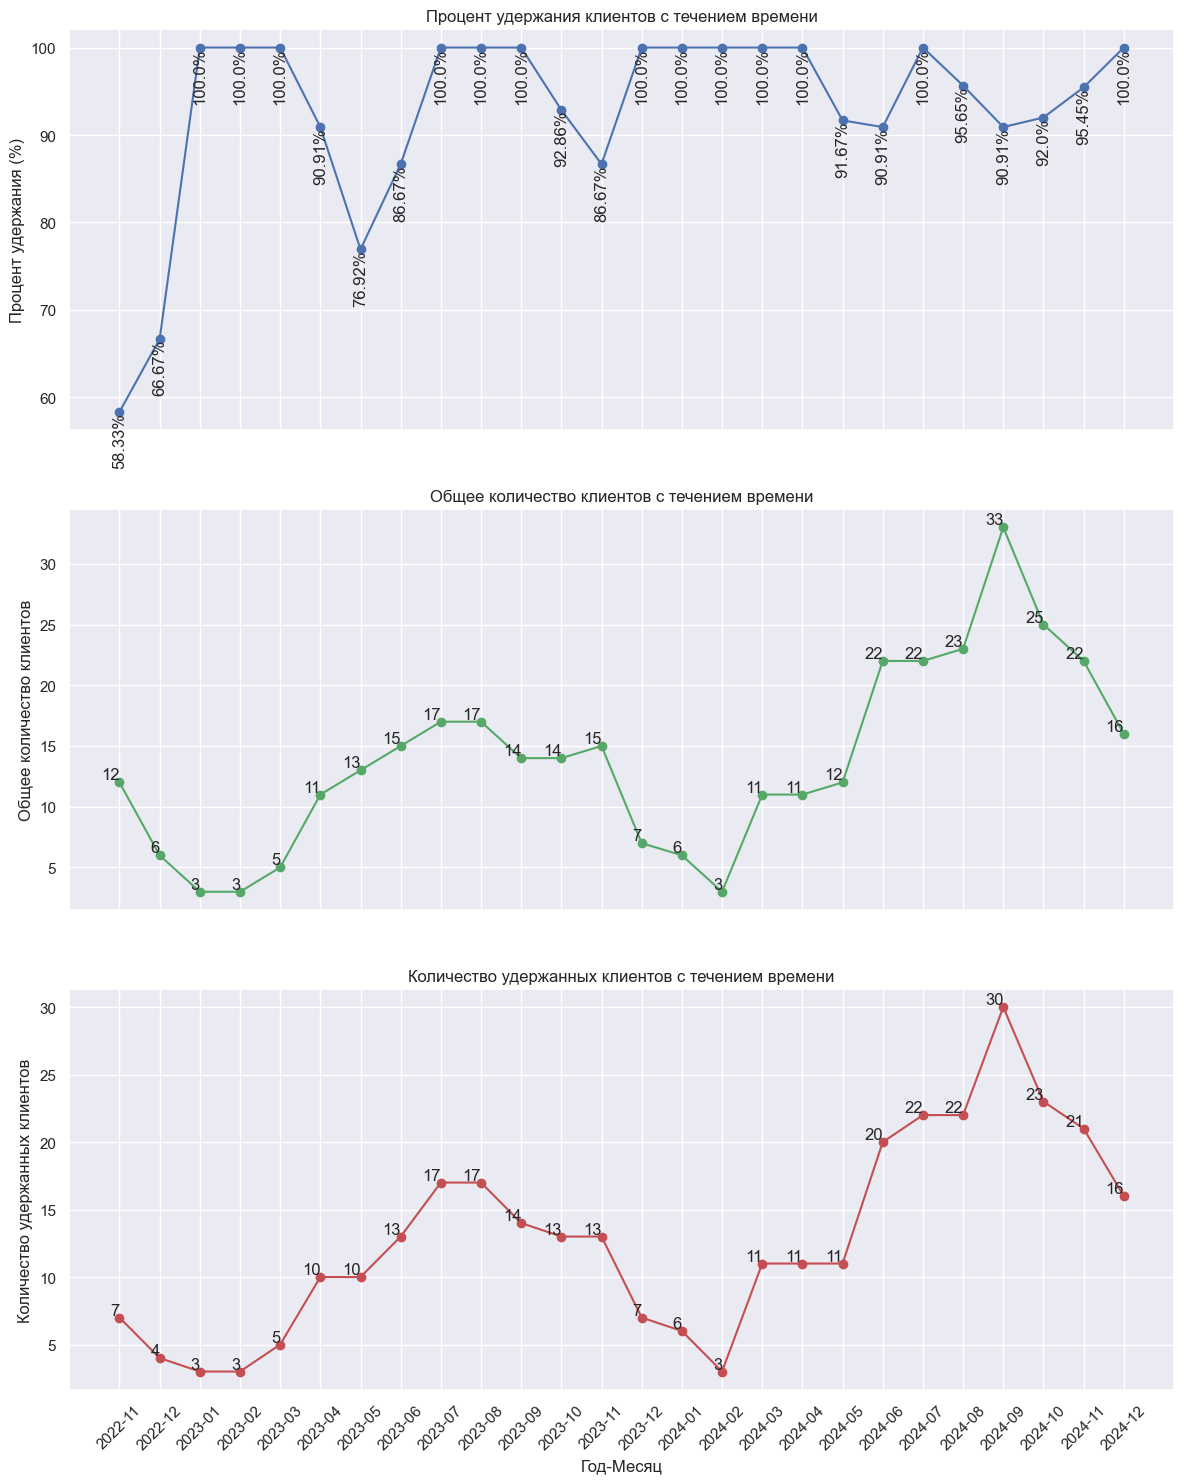

In [57]:
# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
df = pd.read_sql(rr_sql, conn)

# Закрытие соединения с базой данных.
conn.close()

# Создание трех графиков один под другим.
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

# График процента удержания клиентов по месяцам.
ax1.plot(df['year_month'], df['retention_rate'], marker='o', linestyle='-', color='b')
ax1.set_title('Процент удержания клиентов с течением времени')
ax1.set_ylabel('Процент удержания (%)')
ax1.grid(True)

# Добавление подписей процента удержания на точках кривой вертикально под точками.
for i, row in df.iterrows():
    ax1.text(i, row['retention_rate'], f"{row['retention_rate']}%", ha='center', va='top', rotation=90)

# График общего количества клиентов по месяцам.
ax2.plot(df['year_month'], df['total_customers'], marker='o', linestyle='-', color='g')
ax2.set_title('Общее количество клиентов с течением времени')
ax2.set_ylabel('Общее количество клиентов')
ax2.grid(True)

# Добавление показателей на точки графика общего количества клиентов.
for i, row in df.iterrows():
    ax2.text(i, row['total_customers'], f"{row['total_customers']}", ha='right', va='bottom')

# График количества удержанных клиентов по месяцам.
ax3.plot(df['year_month'], df['retained_customers'], marker='o', linestyle='-', color='r')
ax3.set_title('Количество удержанных клиентов с течением времени')
ax3.set_xlabel('Год-Месяц')
ax3.set_ylabel('Количество удержанных клиентов')
ax3.grid(True)

# Добавление подписей количества удержанных клиентов на точках кривой.
for i, row in df.iterrows():
    ax3.text(i, row['retained_customers'], f"{row['retained_customers']}", ha='right', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  # Отображение графика.

На графике можно выделить хорошую тенденцию по коэффициенту удержания - это прежде всего начало 2023 года: 2023-01, 20203-02, 2023-03.
И вторая половина летних месяцев переходящая на первый месяц осени: 2023-07, 20203-08, 2023-09.

Также тенденция сохраняется в декабре 2023 года и начале 2024 года с января по апрель включительно.

В летний период 2024 года тенденция 2023 года не повторилась. Коэффициент удержания был только в июле и в следующие месяцы пошел на небольшой спад. А в декабре 2024 года снова вернулся на 100%.

<a id="4.4-LTV"></a>
### **LTV**
[↑ Наверх](#top)

LTV (Lifetime Value) — это метрика, которая оценивает общую прибыль, которую компания может получить от одного клиента за весь период его взаимодействия с компанией. LTV является важным показателем для оценки долгосрочной ценности клиента и помогает компаниям принимать обоснованные решения о маркетинговых расходах, ценообразовании и стратегиях удержания клиентов.

**Оценка эффективности продуктов и услуг:**

LTV помогает оценить, какие продукты или услуги приносят наибольшую долгосрочную прибыль, что позволяет компаниям сосредоточиться на их улучшении и продвижении.

In [58]:
ltv_sql = '''

-- CTE для вычисления метрик для каждого клиента.
-- avg_orders_value: средняя стоимость заказов клиента.
-- total_orders: общее количество заказов клиента.
-- customer_lifetime: время жизни клиента в годах.

WITH customer_metrics AS (
    SELECT
        customer,
        AVG(amount) AS avg_orders_value,
        COUNT(*) AS total_orders,
        (JULIANDAY('now') - JULIANDAY(MIN(date))) / 365.0 AS customer_lifetime
    FROM sales
    GROUP BY customer
),

-- CTE для вычисления средних метрик по всем клиентам.
-- avg_order_value: средняя стоимость заказов по всем клиентам.
-- purchase_frequency: средняя частота покупок по всем клиентам.
-- avg_customer_lifetime: среднее время жизни клиента в годах.

average_metrics AS (
    SELECT
        AVG(avg_orders_value) AS avg_order_value,
        AVG(total_orders / customer_lifetime) AS purchase_frequency,
        AVG(customer_lifetime) AS avg_customer_lifetime
    FROM customer_metrics
)

-- Основной запрос для вычисления LTV (Lifetime Value) на основе средних метрик.

SELECT
    avg_order_value,
    purchase_frequency,
    avg_customer_lifetime,
    avg_order_value * purchase_frequency * avg_customer_lifetime AS ltv
FROM average_metrics
'''

In [59]:
# Чтение данных из базы данных и загрузка их в датафрейм.
ltv = pd.read_sql(ltv_sql, con=engine)


# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Применение функции форматирования к столбцам avg_order_value и ltv.
ltv['avg_order_value'] = ltv['avg_order_value'].apply(format_number)
ltv['ltv'] = ltv['ltv'].apply(format_number)

# Вывод данных.
ltv

,avg_order_value,purchase_frequency,avg_customer_lifetime,ltv
0,71 315.99,28.23,1.71,3 443 181.84


**avg_order_value** — это средняя стоимость заказов, рассчитанная по всем клиентам. Она показывает, сколько в среднем клиенты тратят на один заказ;

**purchase_frequency** -  это средняя частота покупок, рассчитанная по всем клиентам. Она показывает, как часто в среднем клиенты совершают покупки;

**avg_customer_lifetime** - это среднее время жизни клиента в годах, рассчитанное по всем клиентам. Оно показывает, сколько в среднем времени клиенты остаются активными, то есть совершают покупки;

Расчет показателя **avg_customer_lifetime:**

Целая часть числа равна 1 году. Перевод дробной части в месяцы - Дробная часть числа × 12 = Кол-во месяцев.

Если нужно более точное представление (например, с днями), можно продолжить перевод:

Кол-во месяцев × 30 дней = Кол-во дней.

Итого можно узнать, сколько лет, месяцев и дней клиент в среднем остается с компанией.

**LTV(Lifetime Value)** — это предсказанная стоимость, которую клиент принесет компании за все время своего взаимодействия с ней.

**Просмотрим в разрезе по клиентам за весь период**

In [60]:
ltv_by_customers_sql = '''

-- CTE для вычисления метрик для каждого клиента.
-- avg_orders_value: средняя стоимость заказов клиента.
-- total_orders: общее количество заказов клиента.
-- customer_lifetime: время жизни клиента в годах.

WITH customer_metrics AS (
    SELECT
        customer,
        AVG(amount) AS avg_orders_value,
        COUNT(*) AS total_orders,
        (JULIANDAY('now') - JULIANDAY(MIN(date))) / 365.0 AS customer_lifetime
    FROM sales
    GROUP BY customer
),

-- CTE для вычисления LTV (Lifetime Value) для каждого клиента.
-- purchase_frequency: частота покупок клиента.
-- ltv: Lifetime Value клиента.

customer_ltv AS (
    SELECT
        customer,
        avg_orders_value,
        total_orders,
        customer_lifetime,
        total_orders / customer_lifetime AS purchase_frequency, -- Частота покупок клиента.
        avg_orders_value * (total_orders / customer_lifetime) * customer_lifetime AS ltv -- Lifetime Value клиента.
    FROM customer_metrics
)

-- Основной запрос для вывода метрик и LTV для каждого клиента, отсортированных по LTV в порядке убывания.

SELECT
    customer,
    avg_orders_value,
    purchase_frequency,
    customer_lifetime,
    ltv
FROM customer_ltv
ORDER BY ltv DESC
'''

In [61]:
# Чтение данных из базы данных и загрузка их в датафрейм.
ltv_customers = pd.read_sql(ltv_by_customers_sql, con=engine)

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Применение функции форматирования к столбцам avg_orders_value и ltv.
ltv_customers['avg_orders_value'] = ltv_customers['avg_orders_value'].apply(format_number)
ltv_customers['ltv'] = ltv_customers['ltv'].apply(format_number)

# Вывод данных.
ltv_customers.head(20)

,customer,avg_orders_value,purchase_frequency,customer_lifetime,ltv
0,МИЛКМАСТЕР ООО,139 375.22,96.08,1.96,26 202 541.50
1,Частное лицо,13 576.25,691.69,2.65,24 871 688.32
2,КИРОВСКИЙ ДСК,263 401.23,37.66,2.12,21 072 098.60
3,МЕГАПОЛИС-СНАБ ООО,173 724.99,55.13,1.96,18 762 298.60
4,АРТ ТРЭЙД ООО,130 039.07,50.59,2.65,17 425 235.60
5,СПЕЦЭКОТРАНС ООО,151 278.02,81.12,1.26,15 430 358.40
6,АВТО-ЛОГИСТ ООО,57 018.64,101.45,2.62,15 166 957.20
7,БЕТОНТРЕЙД ООО,77 183.48,76.43,1.86,10 960 054.00
8,КИРОВСКИЕ ЖБИ ООО,94 224.37,52.61,2.03,10 082 008.00
9,ПРОЕКТ-М ООО,98 881.72,53.70,1.77,9 393 763.20


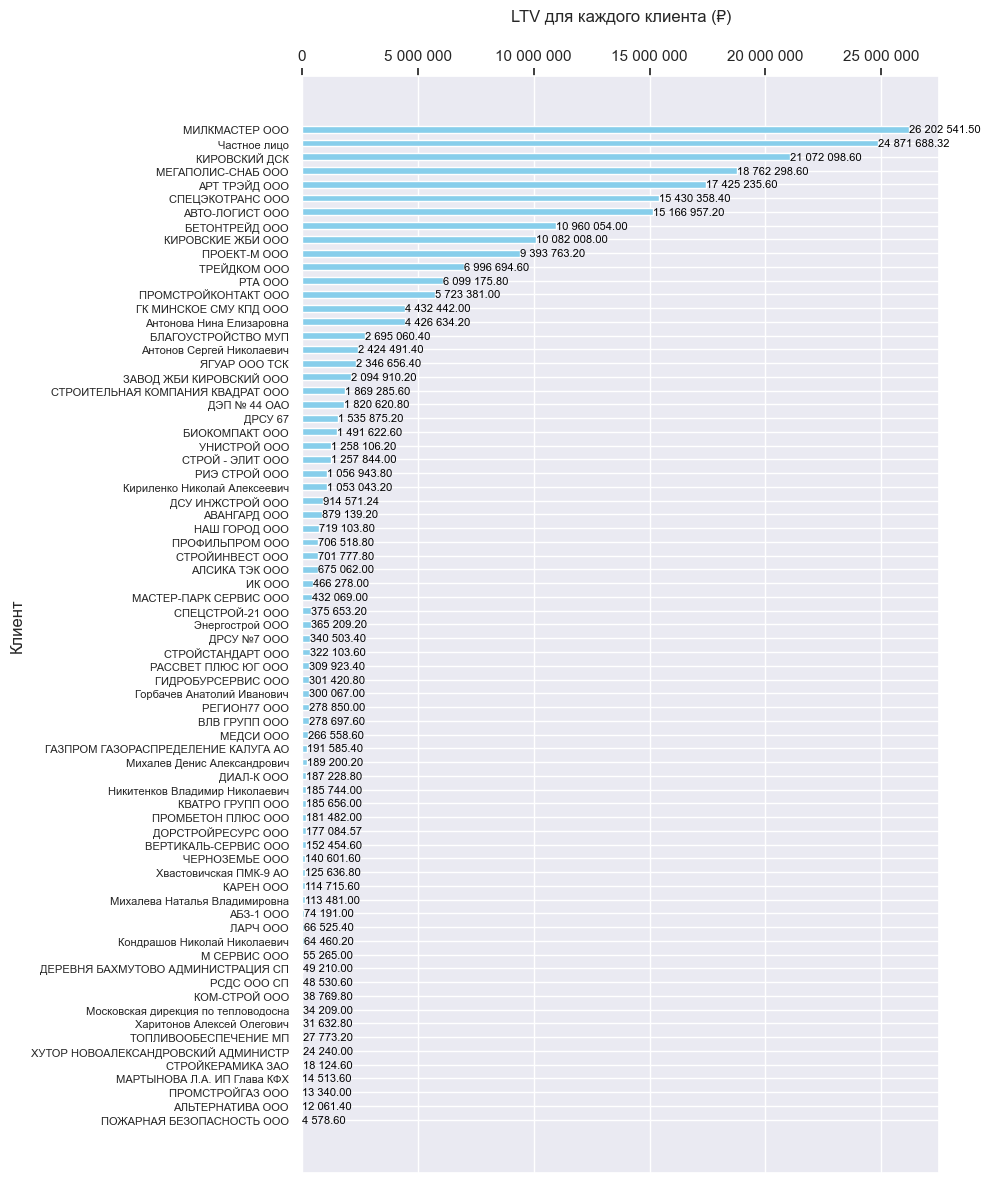

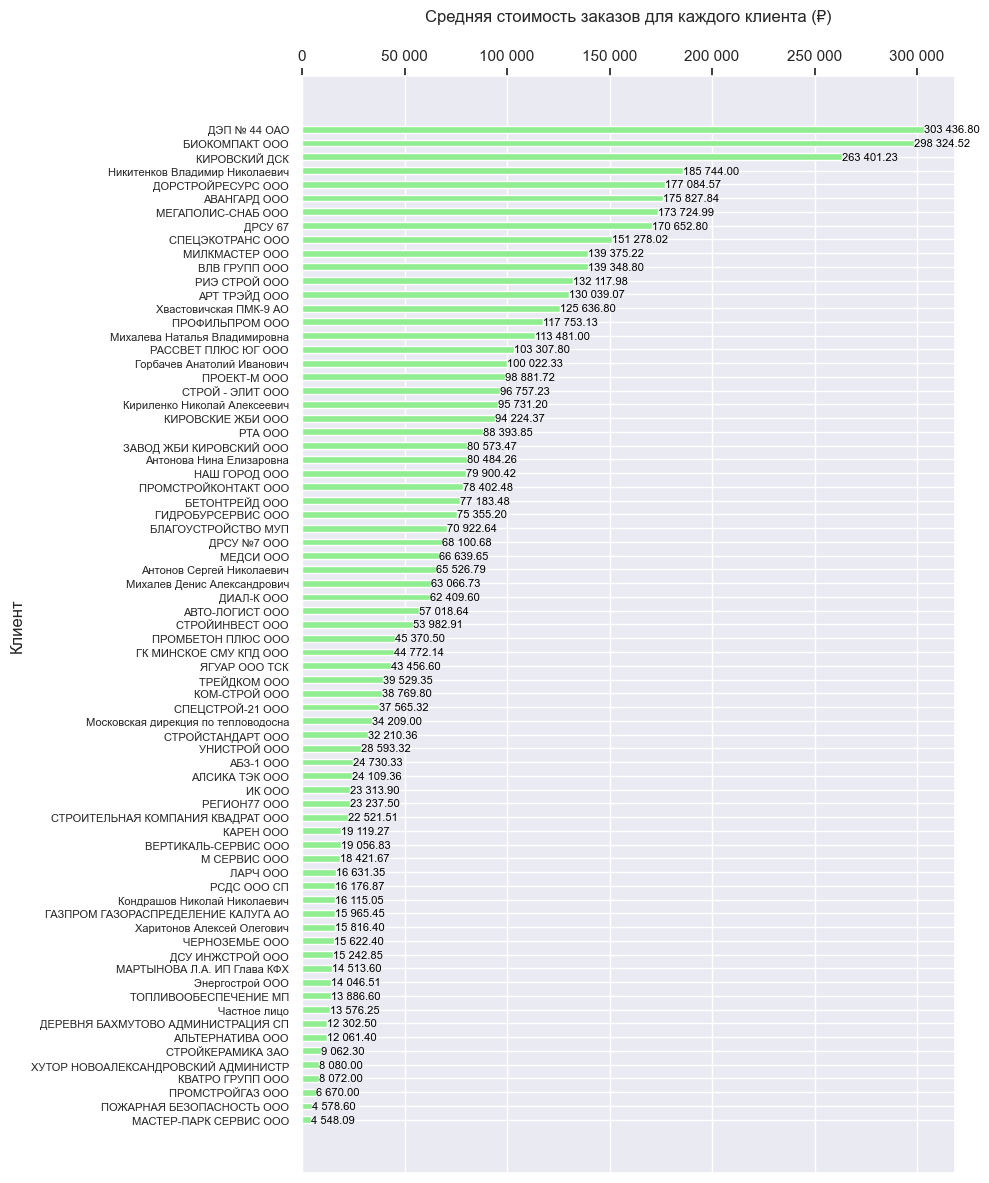

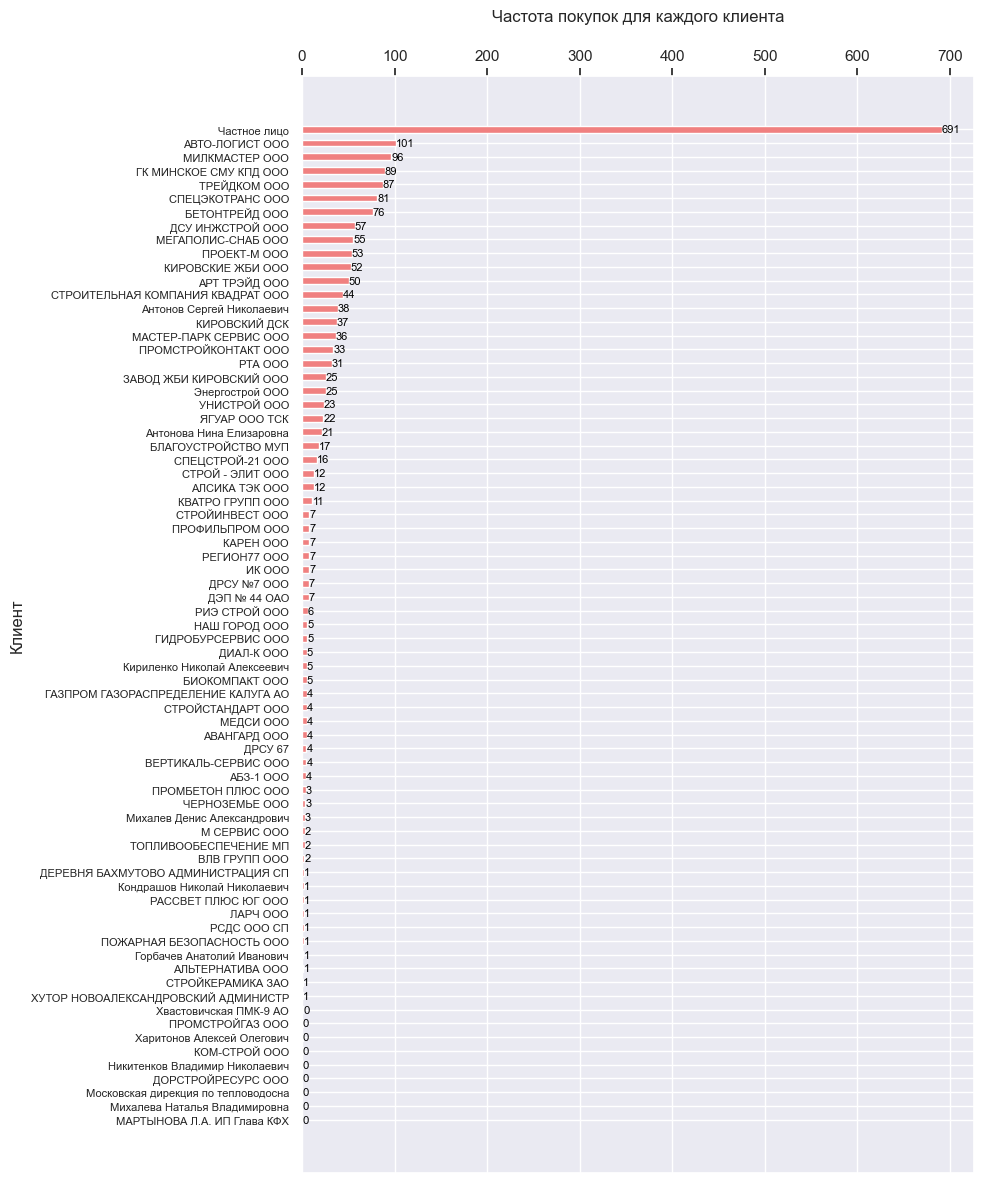

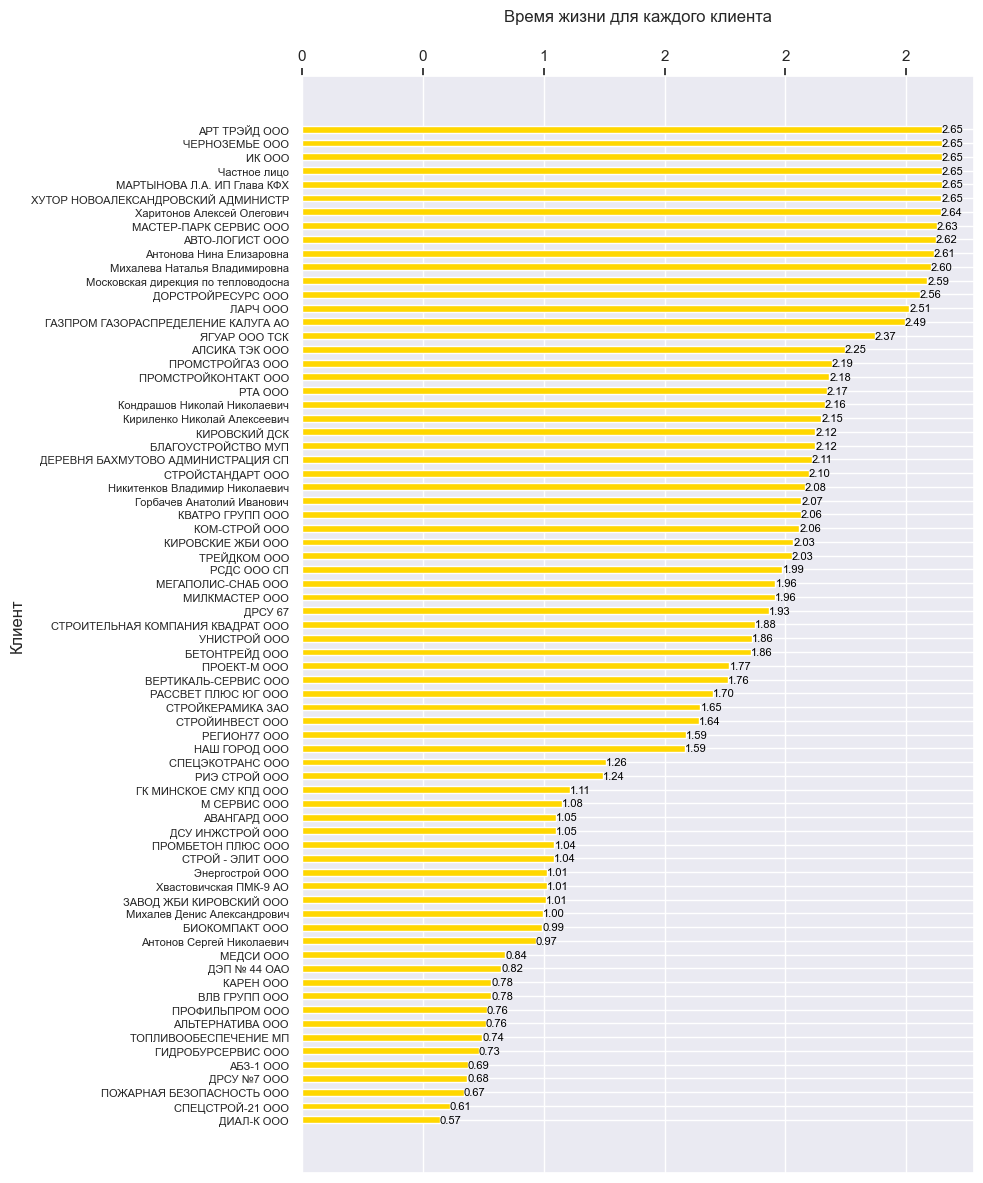

In [62]:
# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
df = pd.read_sql(ltv_by_customers_sql, conn)

# Закрытие соединения с базой данных.
conn.close()

# Очистка данных: удаление строк с None или NaN в столбце 'customer' если такие есть.
df = df.dropna(subset=['customer'])

# Обрезаем названия клиентов до 35 символов.
df['customer'] = df['customer'].str.slice(0, 35)

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Функция для добавления значений.
def add_labels(bars, formatter=format_number):
    for bar in bars:
        height = bar.get_width()
        formatted_height = formatter(height)
        plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                 formatted_height, va='center', ha='left', fontsize=8, color='black')

# Функция для форматирования оси X с разделителем.
def thousands(x, pos):
    return '{:,.0f}'.format(x).replace(',', ' ')

formatter = FuncFormatter(thousands)

# График LTV для каждого клиента.
plt.figure(figsize=(10, 12))
bars = plt.barh(df['customer'], df['ltv'], color='skyblue', height=0.5)
add_labels(bars)  # Добавляем значения.
plt.ylabel('Клиент')
plt.title('LTV для каждого клиента (₽)', pad=20)  # Добавляем отступ для заголовка.
plt.gca().invert_yaxis()  # Инвертируем ось Y, чтобы клиенты с наибольшим LTV были вверху.
plt.yticks(rotation=0, fontsize=8)  # Поворот меток и установка размера шрифта.
plt.gca().xaxis.set_label_position('top')  # Перемещение оси X наверх.
plt.gca().xaxis.set_ticks_position('top')  # Перемещение меток оси X наверх.
plt.gca().xaxis.set_major_formatter(formatter)  # Форматирование оси X.
plt.tight_layout()  # Автоматическая настройка отступов.
plt.show()  # Отображение графика.

# График средней стоимости заказов для каждого клиента.
df_sorted_avg = df.sort_values(by='avg_orders_value', ascending=False)
plt.figure(figsize=(10, 12))
bars = plt.barh(df_sorted_avg['customer'], df_sorted_avg['avg_orders_value'], color='lightgreen', height=0.5)
add_labels(bars)  # Добавляем значения.
plt.ylabel('Клиент')
plt.title('Средняя стоимость заказов для каждого клиента (₽)', pad=20)  # Добавляем отступ для заголовка.
plt.gca().invert_yaxis()  # Инвертируем ось Y, чтобы клиенты с наибольшей средней стоимостью заказов были вверху.
plt.yticks(rotation=0, fontsize=8)  # Поворот меток и установка размера шрифта.
plt.gca().xaxis.set_label_position('top')  # Перемещение оси X наверх.
plt.gca().xaxis.set_ticks_position('top')  # Перемещение меток оси X наверх.
plt.gca().xaxis.set_major_formatter(formatter)  # Форматирование оси X.
plt.tight_layout()  # Автоматическая настройка отступов.
plt.show()  # Отображение графика.

# График частоты покупок для каждого клиента.
df_sorted_freq = df.sort_values(by='purchase_frequency', ascending=False)
plt.figure(figsize=(10, 12))
bars = plt.barh(df_sorted_freq['customer'], df_sorted_freq['purchase_frequency'], color='lightcoral', height=0.5)
add_labels(bars, lambda x: int(x))  # Добавляем целые числа.
plt.ylabel('Клиент')
plt.title('Частота покупок для каждого клиента', pad=20)  # Добавляем отступ для заголовка.
plt.gca().invert_yaxis()  # Инвертируем ось Y, чтобы клиенты с наибольшей частотой покупок были вверху.
plt.yticks(rotation=0, fontsize=8)  # Поворот меток и установка размера шрифта.
plt.gca().xaxis.set_label_position('top')  # Перемещение оси X наверх.
plt.gca().xaxis.set_ticks_position('top')  # Перемещение меток оси X наверх.
plt.gca().xaxis.set_major_formatter(formatter)  # Форматирование оси X.
plt.tight_layout()  # Автоматическая настройка отступов.
plt.show()  # Отображение графика.

# График времени жизни клиента.
df_sorted_lifetime = df.sort_values(by='customer_lifetime', ascending=False)
plt.figure(figsize=(10, 12))
bars = plt.barh(df_sorted_lifetime['customer'], df_sorted_lifetime['customer_lifetime'], color='gold', height=0.5)
add_labels(bars)  # Добавляем значения.
plt.ylabel('Клиент')
plt.title('Время жизни для каждого клиента', pad=20)  # Добавляем отступ для заголовка.
plt.gca().invert_yaxis()  # Инвертируем ось Y, чтобы клиенты с наибольшим временем жизни были вверху.
plt.yticks(rotation=0, fontsize=8)  # Поворот меток и установка размера шрифта.
plt.gca().xaxis.set_label_position('top')  # Перемещение оси X наверх.
plt.gca().xaxis.set_ticks_position('top')  # Перемещение меток оси X наверх.
plt.gca().xaxis.set_major_formatter(formatter)  # Форматирование оси X.
plt.tight_layout()  # Автоматическая настройка отступов.
plt.show()  # Отображение графика.

**LTV для каждого клиента:**

В лидерах МИЛКМАСТЕР ООО - 26 202 541,50₽;

Далее Частное лицо - 24 871 688,32₽;

На третьем месте КИРОВСКИЙ ДСК - 21 072 098,60₽.

**Средняя стоимость заказов для каждого клиента:**

В лидерах ДЭП №44 ОАО - 303 436,80₽;

Далее идет БИОКОМПАКТ ООО - 298 324,52₽;

На третьем месте КИРОВСКИЙ ДСК - 263 401,23₽.

**Частота покупок для каждого клиента:**

В лидерах Частное лицо - 691 покупка;

На втором месте АВТО-ЛОГИСТ ООО - 101 покупка.

**Время жизни для каждого клиента:**

Здесь с одинаковым результатом, с показателем 2,65 делят первое место сразу шестеро:

АРТ ТРЕЙД ООО, ЧЕРНОЗЕМЬЕ ООО, ИК ООО, Частное лицо, МАРТЫНОВА Л.А. ИП Глава КФХ и ХУТОР НОВОАЛЕКСАНДРОВСКИЙ.

<a id="4.5-Общий-объем-продаж"></a>
### **Общий объем продаж**
[↑ Наверх](#top)

In [63]:
total_sales_by_month_sql = '''
SELECT
    strftime('%Y-%m', date) AS year_month,
    SUM(amount) AS total_sales,
    SUM(quantity) AS total_quantity
FROM sales
GROUP BY year_month
'''

In [64]:
# Чтение данных из базы данных и загрузка их в датафрейм.
total_sales_by_month = pd.read_sql(total_sales_by_month_sql, con=engine)

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Применение функции форматирования к столбцам total_sales и total_quantity.
total_sales_by_month['total_sales'] = total_sales_by_month['total_sales'].apply(format_number)
total_sales_by_month['total_quantity'] = total_sales_by_month['total_quantity'].apply(format_number)

# Вывод данных.
total_sales_by_month

,year_month,total_sales,total_quantity
0,2022-11,7 840 173.60,12 383.88
1,2022-12,1 681 403.37,3 278.65
2,2023-01,171 204.00,316.78
3,2023-02,932 876.20,8 834.32
4,2023-03,1 169 415.60,11 899.50
5,2023-04,3 890 088.20,17 168.94
6,2023-05,7 801 843.50,9 486.92
7,2023-06,10 146 799.70,11 693.82
8,2023-07,11 941 058.60,12 941.78
9,2023-08,11 278 194.90,15 233.36


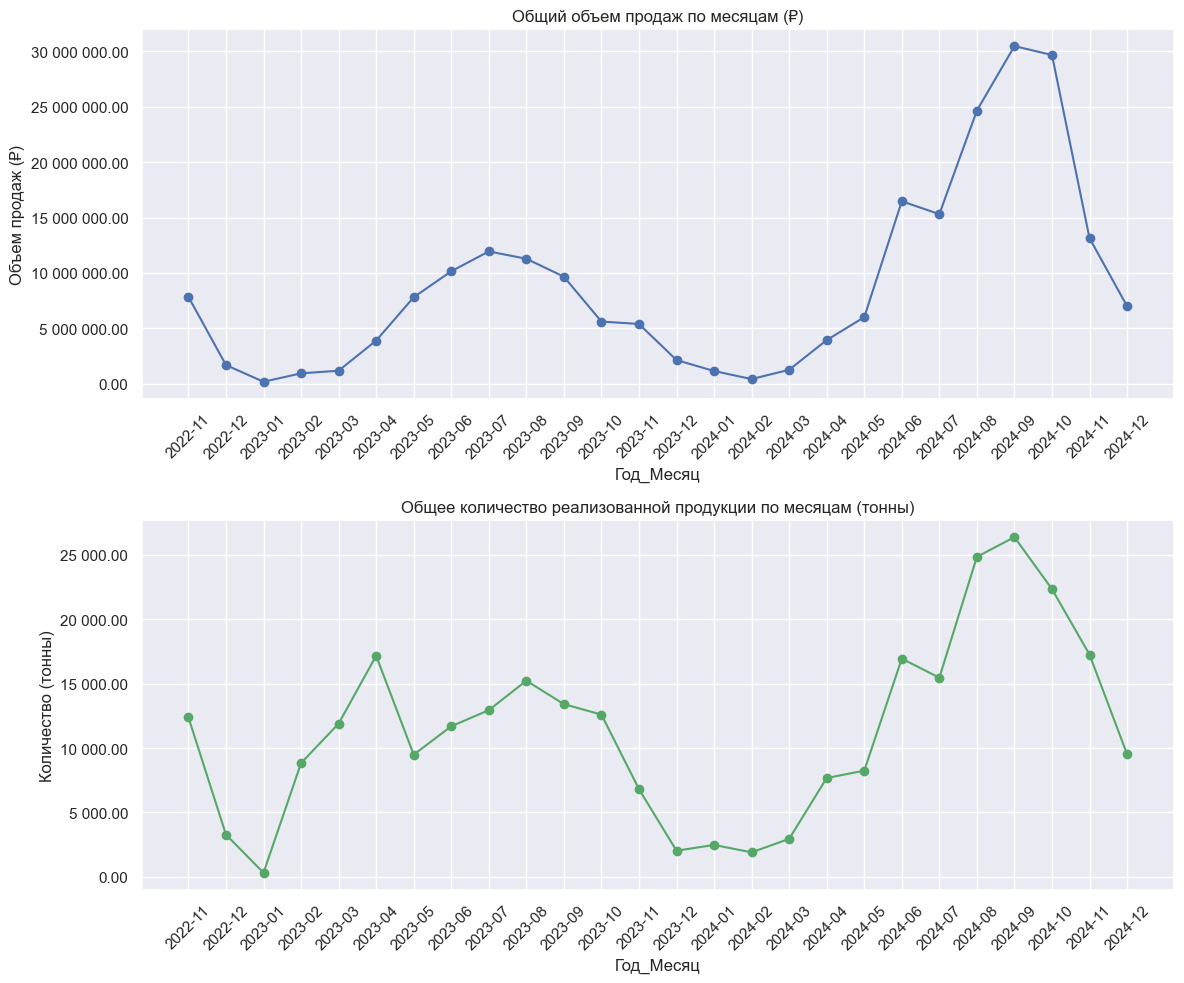

In [65]:
# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
df = pd.read_sql(total_sales_by_month_sql, conn)

# Закрытие соединения с базой данных.
conn.close()

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Функция для форматирования чисел по оси Y.
def format_y_axis(value, _):
    return format_number(value)

# Визуализация данных.
plt.figure(figsize=(12, 10))

# График общих продаж по месяцам.
plt.subplot(2, 1, 1)
ax1 = plt.gca()
plt.plot(df['year_month'], df['total_sales'], marker='o', linestyle='-', color='b')
plt.title('Общий объем продаж по месяцам (₽)')
plt.xlabel('Год_Месяц')
plt.ylabel('Объем продаж (₽)')
plt.grid(True)
plt.xticks(rotation=45)
ax1.yaxis.set_major_formatter(FuncFormatter(format_y_axis))  # Форматирование оси Y.

# График общего количества проданных товаров по месяцам.
plt.subplot(2, 1, 2)
ax2 = plt.gca()
plt.plot(df['year_month'], df['total_quantity'], marker='o', linestyle='-', color='g')
plt.title('Общее количество реализованной продукции по месяцам (тонны)')
plt.xlabel('Год_Месяц')
plt.ylabel('Количество (тонны)')
plt.grid(True)
plt.xticks(rotation=45)
ax2.yaxis.set_major_formatter(FuncFormatter(format_y_axis))  # Форматирование оси Y.

plt.tight_layout()
plt.show()  # Отображение графиков.

На графиках видно, что общие объемы продаж по месяцам и количество реализованной продукции по месяцам коррелируют друг с другом. Пик приходится на 2024 год, это август и сентябрь.

Но, можно заметить, что выбивается значение по количеству продукции на даты 2023-02, 2023-03, 2023-04.
Скорее всего, это связано с тем, что в эти месяцы продавался песок, который имеет небольшую цену, но отгружается в больших объемах.


**Проверим это ниже**

In [66]:
sales_by_product_sql = '''
SELECT
    strftime('%Y-%m', date) AS year_month,
    SUM(amount) AS total_sales,
    SUM(quantity) AS total_quantity,
    product AS product_name
FROM sales
WHERE strftime('%Y-%m', date) BETWEEN '2023-02' AND '2023-04'
GROUP BY year_month, product_name
ORDER BY year_month ASC, product_name ASC
'''

In [67]:
# Чтение данных из базы данных и загрузка их в датафрейм.
sales_by_product = pd.read_sql(sales_by_product_sql, con=engine)

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Применение функции форматирования к столбцам total_sales и total_quantity.
sales_by_product['total_sales'] = sales_by_product['total_sales'].apply(format_number)
sales_by_product['total_quantity'] = sales_by_product['total_quantity'].apply(format_number)

# Вывод данных.
sales_by_product

,year_month,total_sales,total_quantity,product_name
0,2023-02,153 104.00,191.38,Гравий 5х20
1,2023-02,779 772.20,8 642.94,Песок строительный
2,2023-03,61 522.80,70.92,Гравий 20х40
3,2023-03,1 088 552.80,11 813.76,Песок строительный
4,2023-03,19 340.00,14.82,Щебень 5х20
5,2023-04,677 956.40,512.14,Гравий 20х40
6,2023-04,287 827.60,176.12,Гравий 40х70
7,2023-04,1 159 695.00,860.60,Гравий 5х20
8,2023-04,1 655 901.20,15 541.20,Песок строительный
9,2023-04,95 592.00,68.28,Щебень 3х10


Проверка показала, что это обусловлено тем, что в эти месяцы большими объемами вывозился песок. Это и показал график по общему количеству реализованной продукции по месяцам.

А на графике общего объема продаж по месяцам видно, что в деньгах это не такой большой объём. Это показывают графики ниже в разделе 4.6.

**Посмотрим общие объемы продаж по клиентам в каждом месяце**

In [68]:
total_sales_by_client_sql = '''
SELECT
    strftime('%Y-%m', date) AS year_month,
    customer AS client_name,
    SUM(amount) AS total_sales,
    SUM(quantity) AS total_quantity
FROM sales
GROUP BY year_month, client_name
'''

In [69]:
# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Чтение данных из базы данных и загрузка их в датафрейм.
total_sales_by_client = pd.read_sql(total_sales_by_client_sql, conn)

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Применение функции форматирования к столбцам total_sales и total_quantity.
total_sales_by_client['total_sales'] = total_sales_by_client['total_sales'].apply(format_number)
total_sales_by_client['total_quantity'] = total_sales_by_client['total_quantity'].apply(format_number)

# Стилизация.
styled_df = (
    total_sales_by_client
       .style.set_properties(
           subset=['client_name'], **{'white-space': 'normal', 'word-wrap': 'break-word'}) # Перенос по словам 
                                                                                           # для названий клиентов.
       .set_properties(
           subset=['total_sales', 'total_quantity'], **{'white-space': 'nowrap'}) # Предотвращение переноса строк 
                                                                                  # в ячейках с числами.
       .set_table_styles([
           {'selector': 'thead th', 'props': [('text-align', 'center')]},  # Центрирование заголовков.
           {'selector': 'tbody td', 'props': [('text-align', 'right')]}  # Выравнивание текста по правому краю.
       ])
)

# Отображение.
display(styled_df)

,year_month,client_name,total_sales,total_quantity
0,2022-11,АВТО-ЛОГИСТ ООО,502 727.00,1 068.52
1,2022-11,АРТ ТРЭЙД ООО,4 158 226.00,3 730.46
2,2022-11,Антонова Нина Елизаровна,809 568.00,599.68
3,2022-11,ИК ООО,466 278.00,4 662.78
4,2022-11,МАРТЫНОВА Л.А. ИП Глава КФХ,14 513.60,15.44
5,2022-11,МАСТЕР-ПАРК СЕРВИС ООО,15 482.00,154.82
6,2022-11,Михалева Наталья Владимировна,113 481.00,84.06
7,2022-11,Московская дирекция по тепловодоснабжению ОАО,34 209.00,25.34
8,2022-11,ХУТОР НОВОАЛЕКСАНДРОВСКИЙ АДМИНИСТРАЦИЯ (ИСПОЛНИТЕЛЬНО-РАСПОРЯДИТЕЛЬНЫЙ ОРГАН) СЕЛЬСКОГО ПОСЕЛЕНИЯ,24 240.00,46.10
9,2022-11,Харитонов Алексей Олегович,12 084.00,12.72


In [78]:
import plotly.graph_objects as go
from ipywidgets import Dropdown, Output
from IPython.display import display, clear_output
from IPython.display import display as ipy_display

# Подключение к базе данных.
conn = sqlite3.connect('nerud_etl.db')

# Загрузка данных.
total_sales_by_client = pd.read_sql(total_sales_by_client_sql, conn)

# Преобразование year_month в datetime.
total_sales_by_client['year_month'] = pd.to_datetime(total_sales_by_client['year_month'])

# Очистка числовых значений от пробелов и преобразование в float.
total_sales_by_client['total_sales'] = total_sales_by_client['total_sales'].astype(str).str.replace(' ', '', regex=True).astype(float)
total_sales_by_client['total_quantity'] = total_sales_by_client['total_quantity'].astype(str).str.replace(' ', '', regex=True).astype(float)

# Получаем уникальных клиентов.
clients = total_sales_by_client['client_name'].unique()

# Виджет выпадающего списка.
dropdown = Dropdown(
    options=clients,
    value=clients[0],
    description='Клиент:',
    style={'description_width': 'initial'},
    layout={'width': '400px'}
)

output = Output()

def update_graph(change=None):
    selected_client = dropdown.value
    
    # Фильтруем данные по выбранному клиенту.
    client_data = total_sales_by_client[total_sales_by_client['client_name'] == selected_client]
    
    # Создаем график.
    fig = go.Figure()

    # Линия выручки (total_sales).
    fig.add_trace(go.Scatter(
        x=client_data['year_month'],
        y=client_data['total_sales'],
        mode='lines+markers',
        name='Выручка(₽)',
        line=dict(color='blue'),
        yaxis='y1'
    ))

    # Линия количества (total_quantity).
    fig.add_trace(go.Scatter(
        x=client_data['year_month'],
        y=client_data['total_quantity'],
        mode='lines+markers',
        name='Количество(тонны)',
        line=dict(dash='dot', color='red'),
        yaxis='y2'
    ))

    # Настройки макета графика.
    fig.update_layout(
        title=f'Продажи(₽) и Количество(тонны) для клиента: {selected_client}',
        xaxis_title='Год-Месяц',
        yaxis_title='Выручка(₽)',
        yaxis2=dict(
            title='Количество(тонны)',
            overlaying='y',
            side='right',
            tickformat=',.0f',
            dtick=200
        ),
        legend=dict(x=0.05, y=0.95),
        width=900,
        height=600,
        template='plotly_white',
        margin=dict(l=50, r=80, t=80, b=80),
        xaxis=dict(tickformat='%Y-%m', tickangle=45),
        yaxis=dict(tickformat=',.0f', dtick=200_000)  # шаг оси Y (выручка).
    )

    # Сохраняем график как HTML.
    fig.write_html(f"grafik_{selected_client}.html", auto_open=False)
    
    # Очищаем предыдущий вывод и показываем новый график.
    with output:
        output.clear_output(wait=True)
        ipy_display(fig)

# Привязываем функцию к выбору клиента.
dropdown.observe(update_graph, names='value')

# Отображаем интерфейс.
display(dropdown, output)
update_graph()

Dropdown(description='Клиент:', layout=Layout(width='400px'), options=('АВТО-ЛОГИСТ ООО', 'АРТ ТРЭЙД ООО', 'Ан…

Output()

**Примеры графиков:**

- [АВТО-ЛОГИСТ ООО](grafik_АВТО-ЛОГИСТ_ООО.html)
- [АРТ ТРЭЙД ООО](grafik_АРТ_ТРЭЙД_ООО.html)
- [Частное лицо](grafik_Частное_лицо.html)
- [МИЛКМАСТЕР ООО](grafik_МИЛКМАСТЕР_ООО.html)
- [БЛАГОУСТРОЙСТВО МУП](grafik_БЛАГОУСТРОЙСТВО_МУП.html)
- [ПРОЕКТ-М ООО](grafik_ПРОЕКТ-М_ООО.html)
- [ТРЕЙДКОМ ООО](grafik_ТРЕЙДКОМ_ООО.html)
- [СПЕЦЭКОТРАНС ООО](grafik_СПЕЦЭКОТРАНС_ООО.html)
- [НАШ ГОРОД ООО](grafik_НАШ_ГОРОД_ООО.html)
- [МАСТЕР-ПАРК СЕРВИС ООО](grafik_МАСТЕР-ПАРК_СЕРВИС_ООО.html)
- [СТРОЙИНВЕСТ ООО](grafik_СТРОЙИНВЕСТ_ООО.html)
- [ПРОМСТРОЙКОНТАКТ ООО](grafik_ПРОМСТРОЙКОНТАКТ_ООО.html)
- [СТРОИТЕЛЬНАЯ КОМПАНИЯ КВАДРАТ ООО](grafik_СТРОИТЕЛЬНАЯ_КОМПАНИЯ_КВАДРАТ_ООО.html)
- [Энергострой ООО](grafik_Энергострой_ООО.html)
- [РИЭ СТРОЙ ООО](grafik_РИЭ_СТРОЙ_ООО.html)
- [Хвастовичская ПМК-9 АО](grafik_Хвастовичская_ПМК-9_АО.html)
- [ЛАРЧ ООО](grafik_ЛАРЧ_ООО.html)
- [ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕНИЕ КАЛУГА АО](grafik_ГАЗПРОМ_ГАЗОРАСПРЕДЕЛЕНИЕ_КАЛУГА_АО.html)
- [ГК МИНСКОЕ СМУ КПД ООО](grafik_ГК_МИНСКОЕ_СМУ_КПД_ООО.html)
- [ДСУ ИНЖСТРОЙ ООО](grafik_ДСУ_ИНЖСТРОЙ_ООО.html)
- [УНИСТРОЙ ООО](grafik_УНИСТРОЙ_ООО.html)
- [РЕГИОН77 ООО](grafik_РЕГИОН77_ООО.html)
- [АНТОНОВ Сергей Николаевич](grafik_АНТОНОВ_Сергей_Николаевич.html)
- [Антонова Нина Елизаровна](grafik_Антонова_Нина_Елизаровна.html)
- [Кириленко Николай Алексеевич](grafik_Кириленко_Николай_Алексеевич.html)
- [Михалева Наталья Владимировна](grafik_Михалева_Наталья_Владимировна.html)
- [Кондрашов Николай Николаевич](grafik_Кондрашов_Николай_Николаевич.html)
- [Горбачев Анатолий Иванович](grafik_Горбачев_Анатолий_Иванович.html)
- [Завод ЖБИ КИРОВСКИЙ ООО](grafik_Завод_ЖБИ_КИРОВСКИЙ_ООО.html)
- [КВАДРАТ ООО](grafik_КВАДРАТ_ООО.html)
- [КВАТРО ГРУПП ООО](grafik_КВАТРО_ГРУПП_ООО.html)
- [КИРОВСКИЙ ДСК](grafik_КИРОВСКИЙ_ДСК.html)
- [КИРОВСКИЕ ЖБИ ООО](grafik_КИРОВСКИЕ_ЖБИ_ООО.html)
- [МАРТЫНОВА Л.А. ИП Глава КФХ](grafik_МАРТЫНОВА_Л.А._ИП_Глава_КФХ.html)
- [М СЕРВИС ООО](grafik_М_СЕРВИС_ООО.html)
- [Московская дирекция по тепловодоснабжению ОАО](grafik_Московская_дирекция_по_тепловодоснабжению_ОАО.html)
- [ПРОМСТРОЙГАЗ ООО](grafik_ПРОМСТРОЙГАЗ_ООО.html)
- [РАССВЕТ ПЛЮС ЮГ ООО](grafik_РАССВЕТ_ПЛЮС_ЮГ_ООО.html)
- [СТРОЙ - ЭЛИТ ООО](grafik_СТРОЙ_-_ЭЛИТ_ООО.html)
- [СТРОЙСТАНДАРТ ООО](grafik_СТРОЙСТАНДАРТ_ООО.html)
- [СПЕЦСТРОЙ-21 ООО](grafik_СПЕЦСТРОЙ-21_ООО.html)
- [СПЕЦЭКОТРАНС ООО](grafik_СПЕЦЭКОТРАНС_ООО.html)
- [ТРЕЙДКОМ ООО](grafik_ТРЕЙДКОМ_ООО.html)
- [Унистрой ООО](grafik_Унистрой_ООО.html)
- [ЧЕРНОЗЕМЬЕ ООО](grafik_ЧЕРНОЗЕМЬЕ_ООО.html)
- [ЭНЕРГОСТРОЙ ООО](grafik_ЭНЕРГОСТРОЙ_ООО.html)
- [АВАНГАРД ООО](grafik_АВАНГАРД_ООО.html)
- [АЛЬТЕРНАТИВА ООО](grafik_АЛЬТЕРНАТИВА_ООО.html)
- [БЕТОНТРЕЙД ООО](grafik_БЕТОНТРЕЙД_ООО.html)
- [ВЕРТИКАЛЬ-СЕРВИС ООО](grafik_ВЕРТИКАЛЬ-СЕРВИС_ООО.html)
- [ВЛВ ГРУПП ООО](grafik_ВЛВ_ГРУПП_ООО.html)
- [ДИАЛ-К ООО](grafik_ДИАЛ-К_ООО.html)
- [ДОРСТРОЙРЕСУРС ООО](grafik_ДОРСТРОЙРЕСУРС_ООО.html)
- [ИК ООО](grafik_ИК_ООО.html)
- [КАРЕН ООО](grafik_КАРЕН_ООО.html)
- [Квадрат ООО](grafik_Квадрат_ООО.html)
- [МЕГАПОЛИС-СНАБ ООО](grafik_МЕГАПОЛИС-СНАБ_ООО.html)
- [ПРОМСТРОЙКОНТАКТ ООО](grafik_ПРОМСТРОЙКОНТАКТ_ООО.html)
- [РТА ООО](grafik_РТА_ООО.html)
- [СТРОЙКЕРАМИКА ЗАО](grafik_СТРОЙКЕРАМИКА_ЗАО.html)
- [ХУТОР НОВОАЛЕКСАНДРОВСКИЙ АДМИНИСТРАЦИЯ](grafik_ХУТОР_НОВОАЛЕКСАНДРОВСКИЙ_АДМИНИСТРАЦИЯ.html)
- [ЯГУАР ООО ТСК](grafik_ЯГУАР_ООО_ТСК.html)
- [Антонов Сергей Николаевич](grafik_Антонов_Сергей_Николаевич.html)
- [БИОКОМПАКТ ООО](grafik_БИОКОМПАКТ_ООО.html)
- [ВЛВ Групп ООО](grafik_ВЛВ_Групп_ООО.html)
- [ГК МИНСКОЕ СМУ КПД ООО](grafik_ГК_МИНСКОЕ_СМУ_КПД_ООО.html)
- [ДРСУ №7 ООО](grafik_ДРСУ_№7_ООО.html)
- [Квадрат ООО](grafик_Квадрат_ООО.html)
- [Минское СМУ КПД ООО](grafik_Минское_СМУ_КПД_ООО.html)
- [ПРОЕКТ-М ООО](grafik_ПРОЕКТ-М_ООО.html)
- [РАССВЕТ ООО](grafik_РАССВЕТ_ООО.html)

<a id="4.6-Общий-объем-продаж-по-продукции"></a>
### **Общий объем продаж по продукции**
[↑ Наверх](#top)

In [71]:
total_volume_products_sql = '''
SELECT
    product,
    SUM(amount) AS total_sales,
    SUM(quantity) AS total_quantity
FROM sales
WHERE product IS NOT NULL
GROUP BY product
ORDER BY total_sales DESC
'''

In [72]:
# Чтение данных из базы данных и загрузка их в датафрейм.
total_volume_products = pd.read_sql(total_volume_products_sql, con=engine)

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Применение функции форматирования к столбцам total_sales и total_quantity.
total_volume_products['total_sales'] = total_volume_products['total_sales'].apply(format_number)
total_volume_products['total_quantity'] = total_volume_products['total_quantity'].apply(format_number)

# Вывод данных.
total_volume_products

,product,total_sales,total_quantity
0,Щебень 5х20,149 584 238.90,100 085.07
1,Щебень 20х40,41 238 697.02,23 570.01
2,Песок строительный,32 548 003.51,162 730.11
3,Гравий 20х40,2 436 015.60,1 791.80
4,Гравий 5х20,1 916 364.40,1 660.88
5,Щебень 3х10,654 581.20,357.72
6,Песок карьерный,397 289.40,3 682.26
7,Гравий 40х70,314 243.20,202.38
8,Отсев,16 160.00,34.70


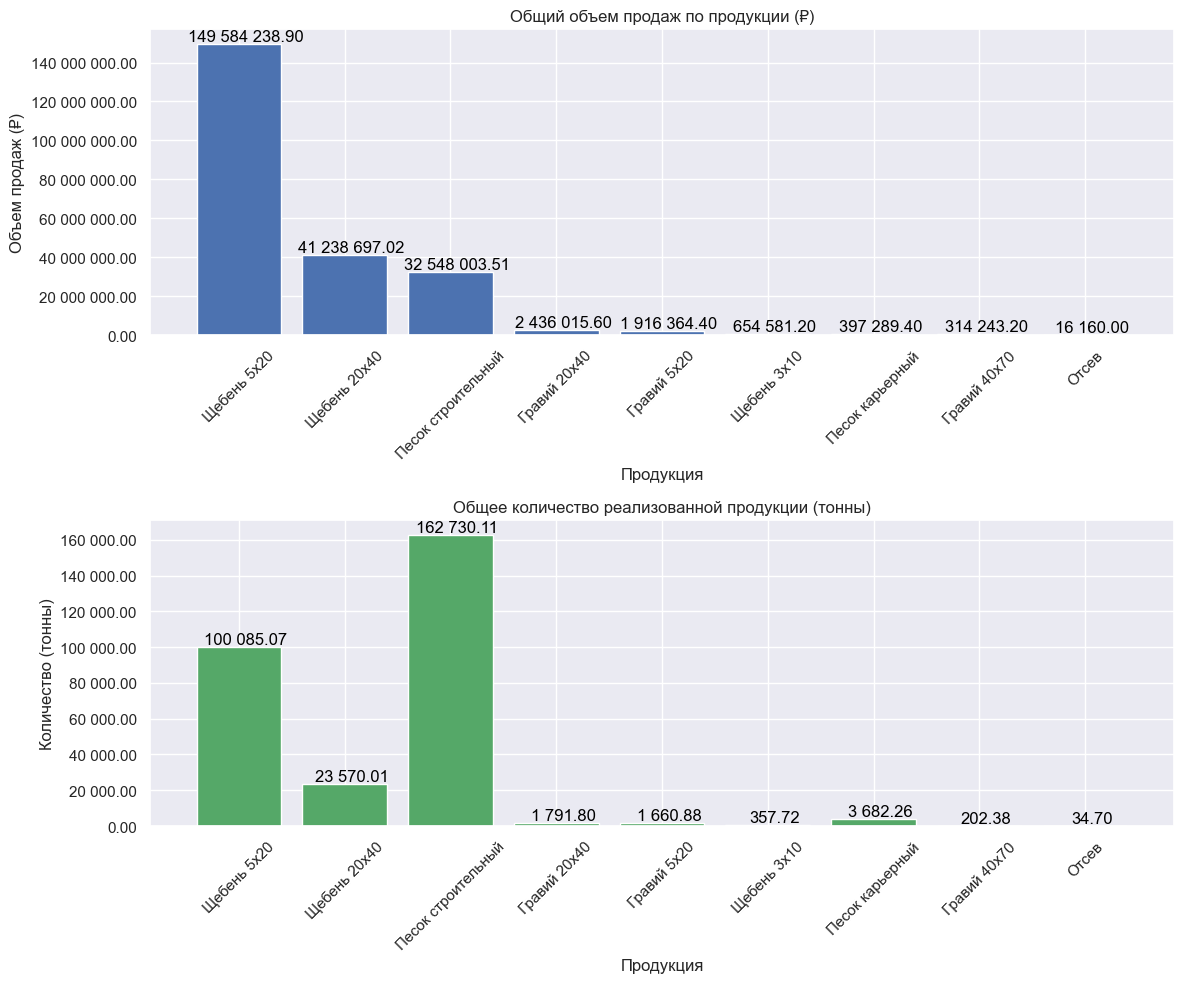

In [73]:
# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
df = pd.read_sql(total_volume_products_sql, conn)

# Закрытие соединения с базой данных.
conn.close()

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Форматирование чисел по оси Y.
def format_y_axis(value, _):
    return format_number(value)

# Функция для добавления аннотаций на график.
def add_annotations(ax, bars):
    for bar in bars:
        height = bar.get_height()
        formatted_height = format_number(round(height, 2))
        ax.annotate(formatted_height,
                    (bar.get_x() + bar.get_width() / 2, height),
                    xytext=(5, 0),  # Смещение вправо на 5 пикселей.
                    textcoords="offset points",
                    ha='center', va='bottom',
                    color='black')

# Визуализация данных.
plt.figure(figsize=(12, 10))

# График общих продаж по продукции.
plt.subplot(2, 1, 1)
bars1 = plt.bar(df['product'], df['total_sales'], color='b')
plt.title('Общий объем продаж по продукции (₽)')
plt.xlabel('Продукция')
plt.ylabel('Объем продаж (₽)')
plt.xticks(rotation=45)
plt.grid(True)
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y_axis))  # Форматирование оси Y.
add_annotations(plt.gca(), bars1)  # Добавление аннотаций на график.

# График общего количества проданной продукции.
plt.subplot(2, 1, 2)
bars2 = plt.bar(df['product'], df['total_quantity'], color='g')
plt.title('Общее количество реализованной продукции (тонны)')
plt.xlabel('Продукция')
plt.ylabel('Количество (тонны)')
plt.xticks(rotation=45)
plt.grid(True)
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y_axis))  # Форматирование оси Y.
add_annotations(plt.gca(), bars2)  # Добавление аннотаций на график.

plt.tight_layout()
plt.show()  # Отображение графиков.

По объёму продаж лидирует Щебень фракции 5х20 - 149 584 238.90₽ (100 085,07 тонн).

А по количеству вывезенной продукции в тоннах - Песок строительный - 162 730.11 тонн с суммой продаж в 32 548 003,51₽.

<a id="4.7-Продажи-продукции-с-01.01.2023-по-28.12.2024-(тонны)"></a>
### **Продажи продукции с 01.01.2023 по 28.12.2024 (тонны)**
[↑ Наверх](#top)

Исключаем остальную продукцию и смотрим в разрезе только трех наименований: Щебень 5х20, Щебень 20х40 и Песок строительный.

In [74]:
total_volume_products_by_month_sql = '''
SELECT strftime('%Y-%m', date) AS year_month,
       product AS product_name,
       SUM(quantity) AS total_volume
FROM sales
WHERE (
      product_name LIKE '%Щебень 5х20%'
      OR product_name LIKE '%Щебень 20х40%'
      OR product_name LIKE '%Песок строительный%')
      AND (strftime('%Y-%m', date) BETWEEN '2023-01' AND '2023-12'
      OR strftime('%Y-%m', date) BETWEEN '2024-01' AND '2024-12')
GROUP BY year_month, product_name
ORDER BY year_month, product_name
'''

In [75]:
# Чтение данных из базы данных и загрузка их в датафрейм.
total_volume_products_by_month = pd.read_sql(total_volume_products_by_month_sql, con=engine)

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Применение функции форматирования к столбцу total_volume.
total_volume_products_by_month['total_volume'] = total_volume_products_by_month['total_volume'].apply(format_number)

# Вывод данных.
total_volume_products_by_month.head(60)

,year_month,product_name,total_volume
0,2023-01,Песок строительный,167.04
1,2023-01,Щебень 5х20,44.42
2,2023-02,Песок строительный,8 642.94
3,2023-03,Песок строительный,11 813.76
4,2023-03,Щебень 5х20,14.82
5,2023-04,Песок строительный,15 541.20
6,2023-04,Щебень 5х20,10.60
7,2023-05,Песок строительный,4 351.22
8,2023-05,Щебень 20х40,35.96
9,2023-05,Щебень 5х20,4 276.48


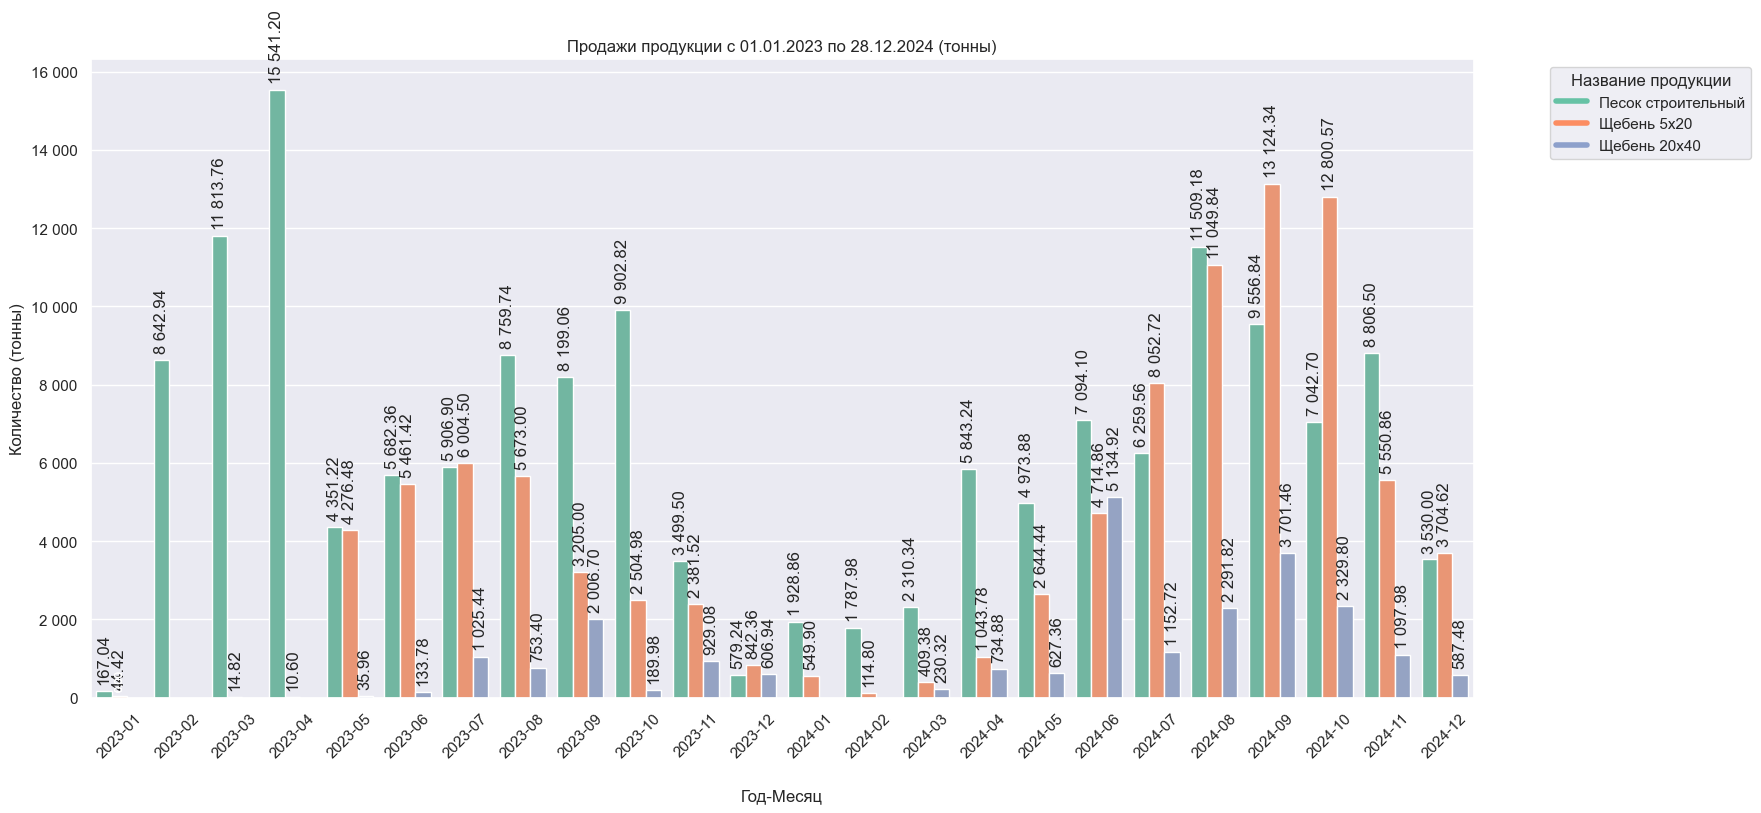

In [76]:
# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
df = pd.read_sql(total_volume_products_by_month_sql, conn)

# Функция для форматирования чисел.
def format_number(x):
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return x

# Визуализация данных.
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='year_month', y='total_volume', hue='product_name', data=df, palette='Set2', dodge=0.9)

# Форматирование оси Y с разделителем.
def thousands(x, pos):
    return '{:,.0f}'.format(x).replace(',', ' ')

formatter = FuncFormatter(thousands)
ax.yaxis.set_major_formatter(formatter)

plt.title('Продажи продукции с 01.01.2023 по 28.12.2024 (тонны)')
plt.xlabel('Год-Месяц', labelpad=20)  # Добавление отступа для метки оси X.
plt.ylabel('Количество (тонны)')
plt.xticks(rotation=45, ha='center')  # Поворачиваем метки оси X и центрируем их.
plt.tight_layout()

# Добавление обозначений данных на столбцы с дробным числом (два знака после запятой).
for p in ax.patches:
    height = p.get_height()
    formatted_height = format_number(height)
    if height < 10:  # Если значение меньше 10, размещаем аннотацию выше столбца.
        ax.annotate(formatted_height,
                    (p.get_x() + p.get_width() / 2., height + 0.1),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points',
                    rotation=90,
                    fontsize=8,
                    color='white')  # Изменение цвета для маленьких значений.
    else:
        ax.annotate(formatted_height,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points',
                    rotation=90)

# Создание легенды.
colors = sns.color_palette('Set2', len(df['product_name'].unique()))
legend_elements = [Line2D([0], [0], color=colors[i], lw=4, label=product)
                   for i, product in enumerate(df['product_name'].unique())]
ax.legend(handles=legend_elements, title='Название продукции', bbox_to_anchor=(1.05, 1), loc='upper left')

# Отображение графика.
plt.show()

# Закрытие соединения с базой данных.
conn.close()

**Здесь смотрим продажи в разрезе двух временных отрезков в сравнении: с 01.01.2023 по 28.12.2023 и с 01.01.2024 по 28.12.2024.**

In [77]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Подключение к базе данных sqlite.
conn = sqlite3.connect('nerud_etl.db')

# Выполнение запроса и загрузка результатов в датафрейм.
df = pd.read_sql(total_volume_products_by_month_sql, conn)

# Обработка пустых значений.
df = df.dropna()

# Функция для добавления отсутствующих месяцев с нулевыми значениями.
def fill_missing_months(df, start_date, end_date):
    date_range = pd.date_range(start=start_date, end=end_date, freq='MS')
    date_range = date_range.strftime('%Y-%m').tolist()
    df_filled = pd.DataFrame({'year_month': date_range})
    df_filled = pd.merge(df_filled, df, on='year_month', how='left').fillna(0)
    return df_filled

# Заполнение отсутствующих месяцев для 2023 года.
df_2023 = df[df['year_month'].between('2023-01', '2023-10')]
df_2023_filled = fill_missing_months(df_2023, '2023-01-01', '2023-10-01')

# Заполнение отсутствующих месяцев для 2024 года.
df_2024 = df[df['year_month'].between('2024-01', '2024-10')]
df_2024_filled = fill_missing_months(df_2024, '2024-01-01', '2024-10-01')

# Форматирование чисел в датафрейме.
pd.options.display.float_format = '{:,.2f}'.format

# Создание палитры цветов для продуктов.
unique_products = pd.unique(df['product_name'])
colors = sns.color_palette('Set2', len(unique_products))
color_map = {
    product: f'rgb({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)})'
    for product, color in zip(unique_products, colors)
}

# Создание подграфиков.
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Продажи 2023', 'Продажи 2024')
)

# Создание линейной диаграммы для 2023 года.
for product in df_2023_filled['product_name'].unique():
    df_product = df_2023_filled[df_2023_filled['product_name'] == product]
    fig.add_trace(
        go.Scatter(
            x=df_product['year_month'],
            y=df_product['total_volume'],
            mode='lines+markers',
            name=f'{product} (2023)',
            line=dict(color=color_map[product]),
            text=df_product['total_volume'].apply(lambda x: f"{x:,.2f}".replace(",", " ")),  # Форматирование чисел.
            hovertemplate='%{x}: %{text} тонн'  # Форматирование всплывающей подсказки.
        ),
        row=1, col=1
    )

# Создание линейной диаграммы для 2024 года.
for product in df_2024_filled['product_name'].unique():
    df_product = df_2024_filled[df_2024_filled['product_name'] == product]
    fig.add_trace(
        go.Scatter(
            x=df_product['year_month'],
            y=df_product['total_volume'],
            mode='lines+markers',
            name=f'{product} (2024)',
            line=dict(color=color_map[product]),
            text=df_product['total_volume'].apply(lambda x: f"{x:,.2f}".replace(",", " ")),  # Форматирование чисел.
            hovertemplate='%{x}: %{text} тонн'  # Форматирование всплывающей подсказки.
        ),
        row=1, col=2
    )

# Форматирование графиков.
fig.update_layout(
    height=500, width=1000,
    title_text="Продажи продукции по месяцам (тонны)",
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="right",
        x=1.3,  # Увеличиваем отступ справа.
        font=dict(size=10)
    ),
    margin=dict(r=200)  # Увеличиваем правый отступ.
)
fig.update_xaxes(title_text="Год-Месяц", row=1, col=1)
fig.update_xaxes(title_text="Год-Месяц", row=1, col=2)
fig.update_yaxes(title_text="Количество (тонны)", row=1, col=1)
fig.update_yaxes(title_text="Количество (тонны)", row=1, col=2)

# Сохранение графика как изображение.
fig.write_image("sales_plot.png")

# Отображение графиков.
fig.show()

# Закрытие соединения с базой данных.
conn.close()

![Продажи продукции по месяцам (тонны)](sales_plot.png)

В разрезе объема продаж продукции с 01-01.2023 по 28-12.2024 видно, что в основном большую часть составляет Песок строительный - в апреле 2023 пик отгрузки 15 541,20 тонны.

Далее идет Щебень 5х20 - пиковые значения реализации в сентябре 2024 года - 13 124,34 тонны.

И меньше всего вывозят Щебень 20х40 - пиковые значения по отгрузкам в июне 2024 года - 5 134,92 тонны.

<a id="5-Шаг-4.-Вывод"></a>
## **Шаг 4. Вывод**
[↑ Наверх](#top)

В датасете присутствует 5 столбцов, он состоит из 4285 наблюдений. Вес 167.5+ KB.

Дубликаты и пропуски отсутствуют.

Столбец Реализация (акт, накладная, УПД).Дата - приведен к формату datetime.

Столбцы датасета переименованы для лучшего взаимодействия с данными.

**При составлении RFM анализа выявлены клиенты:**

В группе 111, клиенты, которые больше всего приносили в денежном выражении.

Если смотреть по сегментам, то:

'Лучшие' - 139 652 605.26₽, 13 клиентов;

'Хорошие' - 44 789 565.80₽, 8 клиентов;

'Средние' - 26 200 392.60₽, 16 клиентов;

'Ниже среднего' - 13 817 117.40₽, 20 клиентов;

'Плохие' - 4 645 912.17₽, 16 клиентов.

**При составлении Среднего чека выявлено:**

Средняя сумма потраченная одним клиентом за весь рассматриваемый период с 01.11.2022 по 28.12.2024 года.

Больше всего средний чек у трёх компании:

ДЭП № 44 ОАО - средний чек 303 436.80₽;

Ниже идет компания БИОКОМПАКТ ООО - средний чек 298 324.52₽;

На третьем месте КИРОВСКИЙ ДСК - средний чек 263 401.23₽;

и далее по списку.

Если смотреть среднюю сумму потраченную одним клиентом по продукции за весь период, то здесь примечательно что ДЭП № 44 ОАО уже не в лидерах.

Сначала идет КИРОВСКИЙ ДСК выберает Щебень 20х40 в среднем на 382 500.56₽, Щебень 5х20 на 240 496.48₽;

далее БИОКОМПАКТ ООО выберает Щебень 5х20 в среднем на 323 787.50₽, Щебень 20х40 на 281 349.20₽;

и ДЭП № 44 ОАО выберает Щебень 20х40 в среднем на 303 436.80₽.

**При составлении Коэффициента удержания (Retention Rate) выявлено:**

Тут можно выделить хорошую тенденцию по коэффициенту удержания - это прежде всего начало 2023 года: 2023-01, 20203-02, 2023-03. И вторая половина летних месяцев переходящая на первый месяц осени: 2023-07, 20203-08, 2023-09.

Также тенденция сохраняется в декабре 2023 года и начале 2024 года с января по апрель включительно.

В летний период 2024 года тенденция 2023 года не повторилась. Коэффициент удержания был только в июле и в следующие месяцы пошел на небольшой спад. А в декабре 2024 года снова вернулся на 100%.

**При составлении LTV выявлено:**

LTV для Топ-3 клиента:

В лидерах МИЛКМАСТЕР ООО - 26 202 541,50₽;

Далее Частное лицо - 24 871 688,32₽;

На третьем месте КИРОВСКИЙ ДСК - 21 072 098,60₽.

**Средняя стоимость заказов для каждого клиента:**

В лидерах ДЭП №44 ОАО - 303 436,80₽;

Далее идет БИОКОМПАКТ ООО - 298 324,52₽;

На третьем месте КИРОВСКИЙ ДСК - 263 401,23₽.

**Частота покупок для каждого клиента:**

В лидерах Частное лицо - 691 покупка;

На втором месте АВТО-ЛОГИСТ ООО - 101 покупка.

**Время жизни для каждого клиента:**

Здесь с одинаковым результатом, с показателем 2,65 делят первое место сразу шестеро:

АРТ ТРЕЙД ООО, ЧЕРНОЗЕМЬЕ ООО, ИК ООО, Частное лицо, МАРТЫНОВА Л.А. ИП Глава КФХ и ХУТОР НОВОАЛЕКСАНДРОВСКИЙ.

**При составлении Общего объема продаж по клиентам выявлено:**

Общие объемы продаж по месяцам и количество реализованной продукции по месяцам коррелируют друг с другом. Пик приходится на 2024 год, это август и сентябрь.
Но, можно заметить, что выбивается значение по количеству продукции на даты 2023-02, 2023-03, 2023-04.  Это связано с тем, что в эти месяцы продавался строительный песок, который имеет небольшую цену, но отгружается в больших количествах.

**При составлении Общего объема продаж по продукции выявлено:**

По объёму продаж лидирует Щебень фракции 5х20 - 149 584 238.90₽ (100 085,07 тонн).

А по количеству вывезенной продукции в тоннах - Песок строительный - 162 730.11 тонн с суммой продаж в 32 548 003,51₽.

**При составлении продаж продукции с 01.01.2023 по 28.12.2023 и с 01.01.2024 по 28.12.2024 (тонны) - выявлено:**

Здесь смотрим продажи в разрезе вдух временных отрезков в сравнении: с 01.01.2023 по 01.10.2023 и с 01.01.2024 по 01.10.2024.

Также исключаем остальную продукцию и смотрим в разрезе только трех наименований: Щебень 5х20, Щебень 20х40 и Песок строительный.

В разрезе объема продаж продукции с 01-10.2023 по 01-10.2024 видно, что в основном большую часть составляет Песок строительный - в апреле 2023 пик отгрузки 15 541,20 тонны.

Далее идет Щебень 5х20 - пиковые значения реализации в сентябре 2024 года - 13 124,34 тонны.

И меньше всего вывозят Щебень 20х40 - пиковые значения по отгрузкам в июне 2024 года - 5 134,92 тонны.

<a id="6-Шаг-5.-Ссылка-на-визуализацию"></a>
## **Шаг 5. Ссылка на визуализацию**
[↑ Наверх](#top)

https://public.tableau.com/app/profile/roman.ivashov/viz/-sales/Story1